# Benchmark Experiments Logs Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import logs_parser
import os
import subprocess
from matplotlib.lines import Line2D
from math import ceil
plt.rcParams.update({'figure.figsize': (16, 8), 'figure.autolayout': True})


# Experiments Log Paths
Relative logs path from this notebook location

In [2]:
cwd = os.getcwd()
subscriber_logs = f'{cwd}/../subscriber/logs/'
publishers_logs = f'{cwd}/../publisher/logs/'
#transformer_logs= f'{cwd}/../transformer/logs/'

resource_stats_vm1=f'{cwd}/../subscriber/logs/'
#resource_stats_vm2=f'{cwd}/../transformer/logs/'

# Benchmark Parameters
Benchmark parameters used in the setup for execution of the system under test.

In [3]:
# ── Experiment selection ─────────────────────────────────────────────────────
auts = [
    'aut0_hivemq_125kb',       'aut0_hivemq_125kb_fixed',
    'aut0_emqx_125kb',         'aut0_emqx_125kb_fixed',
    'aut0_mosquitto_125kb',    'aut0_mosquitto_125kb_fixed',
    'aut0_rabbitmq_125kb',     'aut0_rabbitmq_125kb_fixed',
    'aut0_nanomq_125kb',       'aut0_nanomq_125kb_fixed',
]
qoss = ['qos0']
gateways = []
gateways_payloads = []
providers_tp = []
gateway_topics = []

# Benchmark Setups Evalutated
Iterate over the benchmark setups using the experiments log folders structure.

Architectural Options Under Test (AUT):
- **AUT1_15b** - Architectural Option 1: One bridge transformer per data provider (total of 2 transformers deployed)
- **AUT1_29b** - Architectural Option variation: After the benchmark results analysis, further data was needed to investigate the topic name overhead between AUT1 and AUT2. We conducted a third exeperiement mapping the topic names from the ingestion broker (source), and the destination broker to which the subscriber connects with
- **AUT2** - Architectural Option 2: One bridge transformer per sensor hub data stream (total of 4 transformers deployed)

MQTT Clients end-to-end Quality-of-Service (QoS):
- **QoS level 0** - At most once: prone to message lost
- **QoS level 1** - At least once: prone to duplicated message delivery
- **QoS level 2** - Exactly once: message delivery guarantee with no duplicates

## Setups (9):
1. AUT1.15b - QoS 0
2. AUT1.15b - QoS 1
3. AUT1.15b - QoS 2
4. AUT1.29b - QoS 0
8. AUT1.29b - QoS 1
9. AUT1.29b - QoS 2
5. AUT2 - QoS 0
6. AUT2 - QoS 1
7. AUT2 - QoS 2
   

# Global Results - Table IV
Arithmethic means of all repetitions per execution of each benchmark setup listed above

In [4]:
%load_ext autoreload
%autoreload 2

dtype = [
    ('timestamp','datetime64[s]'),
    ('uuid','U64'),
    ('latency','f8'),
    ('topic','U32'),
    ('payload_size','i4'),
    ('topic_size','i4'),
    ('order','i4'),
    ('aut','U32'),
    ('qos','U8'),
    ('gateway','U16')
]

np_array_global = np.empty(0, dtype=dtype)
total_log_entries = 0

for aut in auts:
    for qos in qoss:
        aut_pub_log_folder = os.path.join(publishers_logs, aut, qos)
        aut_sub_log_folder = os.path.join(subscriber_logs, aut, qos)

        print(f'\n{aut.upper()}/{qos.upper()}')
        print(f'  Publisher : {aut_pub_log_folder}')
        print(f'  Subscriber: {aut_sub_log_folder}')

        load = logs_parser.get_sub_logs(aut_sub_log_folder)
        if len(load) == 0:
            continue

        # Infer num_runs from publisher log file count and update module constant
        logs_parser.NUM_RUNS = logs_parser.infer_num_runs(aut_pub_log_folder)
        num_runs = logs_parser.NUM_RUNS
        print(f'  Runs detected: {num_runs}')

        # Count successful publishes from publisher logs
        try:
            pub_command = f"grep -rnw \"rc: Success\" {aut_pub_log_folder} | wc -l"
            published_msgs = int(subprocess.check_output(pub_command, shell=True, text=True).strip())
            print(f'  Published messages (rc:Success): {published_msgs}')
        except subprocess.CalledProcessError as e:
            print(f'  [warn] Could not count published messages: {e}')
            published_msgs = None

        # Parse subscriber logs (no transformer in AUT0)
        np_array = logs_parser.get_numpy_array_pub_sub(load)
        total_log_entries += len(np_array)

        new_array = np.empty(np_array.shape, dtype=dtype)
        for name in np_array.dtype.names:
            new_array[name] = np_array[name]

        new_array['aut'] = aut
        new_array['qos'] = qos

        # Derive gateway from topic:
        #   AUT0: site1/gateway1/hub1       → 'gateway1'
        #   AUT1: site1/provider1/gateway1/hub1 → 'provider1.gateway1'
        def _gateway_from_topic(t):
            parts = t.split('/')
            if len(parts) >= 2 and not parts[1].startswith('provider'):
                return parts[1]                         # AUT0
            if len(parts) >= 3:
                return parts[1] + '.' + parts[2]        # AUT1/AUT2
            return parts[1] if len(parts) >= 2 else 'unknown'

        new_array['gateway'] = np.array([_gateway_from_topic(t) for t in np_array['topic']])
        np_array_global = np.concatenate((np_array_global, new_array))

        delay = logs_parser.get_np_stats(np_array['latency'])
        rcv_msgs = len(np_array)
        avg_rcv_msgs = rcv_msgs / num_runs
        uniques = np.sum(np.unique_counts(np_array['uuid']).counts)
        duplicates_count = rcv_msgs - uniques
        avg_duplicates = duplicates_count / num_runs
        # Expected = published msgs (or re-derived if not available).
        # AUT0: both providers send to the same gateway topics, so
        # expected = 2 * NUM_MSG * num_runs per gateway pair.
        if published_msgs is not None:
            expected_total = published_msgs
        else:
            # fallback: 2 providers × 2 gateways × NUM_MSG × num_runs
            expected_total = 2 * 2 * logs_parser.NUM_MSG * num_runs
        lost_msgs = logs_parser.get_lost_messages(load, expected=expected_total)
        # True unique-message loss: messages never received even once
        true_lost = expected_total - uniques
        avg_lost_msg = true_lost / num_runs
        topic_size = logs_parser.get_np_stats(np_array['topic_size'])
        payload = logs_parser.get_np_stats(np_array['payload_size'])

        print(f'  Received={rcv_msgs} (expected={expected_total}) | avg/run={avg_rcv_msgs:.1f} | avg_lost/run={avg_lost_msg:.1f} | avg_dup/run={avg_duplicates:.1f}  → loss_rate={100*true_lost/expected_total:.2f}%')
        print(f'  Latency avg={delay["avg"]:.2f}ms  std={delay["stdev"]:.2f}ms  min={delay["min"]:.2f}  max={delay["max"]:.2f}')
        print(f'  Avg payload={payload["avg"]:.0f}B')
        print('  ' + '-'*70)

assert np_array_global.shape[0] == total_log_entries



AUT0_HIVEMQ_125KB/QOS0
  Publisher : /home/heilo/benchmark/mqtt_benchmark/data_analysis/../publisher/logs/aut0_hivemq_125kb/qos0
  Subscriber: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../subscriber/logs/aut0_hivemq_125kb/qos0
Log entries: 5247
Discarded log entries: 0
  Runs detected: 10
  Published messages (rc:Success): 40000
  Received=5247 (expected=40000) | avg/run=524.7 | avg_lost/run=3475.3 | avg_dup/run=0.0  → loss_rate=86.88%
  Latency avg=8.31ms  std=29.23ms  min=3.87  max=874.32
  Avg payload=128000B
  ----------------------------------------------------------------------

AUT0_HIVEMQ_125KB_FIXED/QOS0
  Publisher : /home/heilo/benchmark/mqtt_benchmark/data_analysis/../publisher/logs/aut0_hivemq_125kb_fixed/qos0
  Subscriber: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../subscriber/logs/aut0_hivemq_125kb_fixed/qos0


/home/heilo/benchmark/mqtt_benchmark/data_analysis/logs_parser.py:109: UserWarning: no explicit representation of timezones available for np.datetime64
  np.datetime64(timestamp),


Log entries: 40000
Discarded log entries: 0
  Runs detected: 10
  Published messages (rc:Success): 40000
  Received=40000 (expected=40000) | avg/run=4000.0 | avg_lost/run=0.0 | avg_dup/run=0.0  → loss_rate=0.00%
  Latency avg=18.33ms  std=11.80ms  min=-42.61  max=619.37
  Avg payload=128000B
  ----------------------------------------------------------------------

AUT0_EMQX_125KB/QOS0
  Publisher : /home/heilo/benchmark/mqtt_benchmark/data_analysis/../publisher/logs/aut0_emqx_125kb/qos0
  Subscriber: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../subscriber/logs/aut0_emqx_125kb/qos0
Log entries: 39085
Discarded log entries: 0
  Runs detected: 10
  Published messages (rc:Success): 40000
  Received=39085 (expected=40000) | avg/run=3908.5 | avg_lost/run=91.5 | avg_dup/run=0.0  → loss_rate=2.29%
  Latency avg=7.31ms  std=22.81ms  min=4.00  max=1085.98
  Avg payload=128000B
  ----------------------------------------------------------------------

AUT0_EMQX_125KB_FIXED/QOS0
  Publishe

In [5]:
# ── Payload-size helpers (used by all split-by-payload plots below) ──────────
_ps_values = sorted(int(x) for x in np.unique(np_array_global['payload_size']))

def _ps_label(ps):
    if ps >= 1_000_000:
        return f"{ps // 1_000_000} MB"
    return f"{ps // 1_000} KB"

_BROKER_NAMES = {
    'hivemq': 'HiveMQ', 'emqx': 'EMQX', 'mosquitto': 'Mosquitto',
    'rabbitmq': 'RabbitMQ', 'nanomq': 'NanoMQ',
}

def _broker_label(aut):
    parts = aut.split('_')
    return _BROKER_NAMES.get(parts[1] if len(parts) >= 2 else aut, aut)


## Global Latency Overview

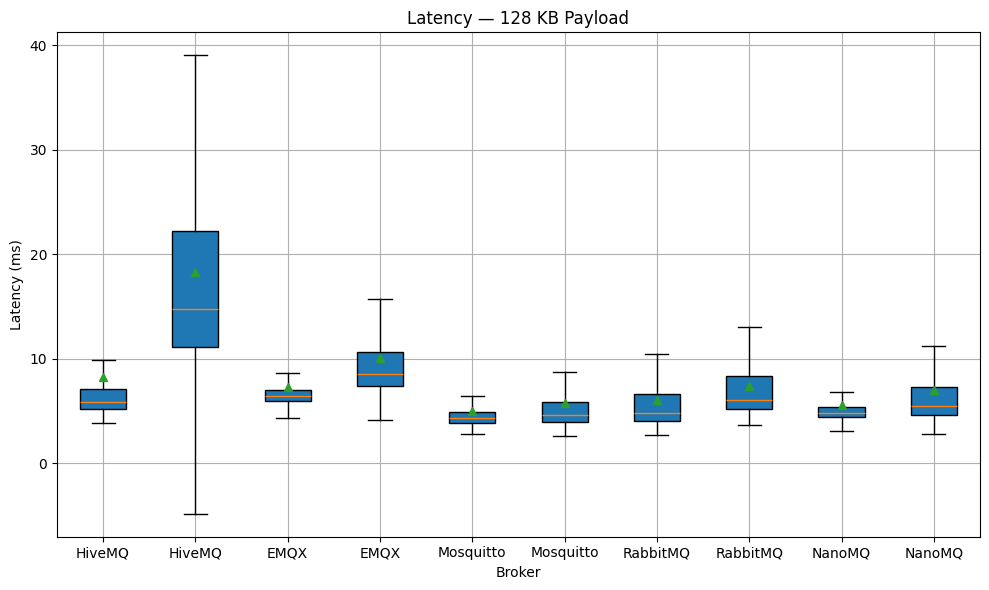

In [6]:
# Global latency boxplot — one figure per payload size
for ps in _ps_values:
    latency_data = []
    labels = []
    for aut in auts:
        data = np_array_global[(np_array_global['payload_size'] == ps) & (np_array_global['aut'] == aut)]['latency']
        if len(data) == 0:
            print(f'  [warn] No data for {aut}/{ps}, excluded.')
            continue
        latency_data.append(data)
        labels.append(_broker_label(aut))

    if not latency_data:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(latency_data, patch_artist=True, showfliers=False, showmeans=True)
    ax.yaxis.grid(True)
    ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.set_xlabel('Broker')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(f'Latency — {_ps_label(ps)} Payload')
    plt.grid(True)
    plt.savefig(f"Global_latency_boxplot_{_ps_label(ps).replace(' ', '_')}.pdf")
    plt.show()


### Global Latency Filtered By QoS Level

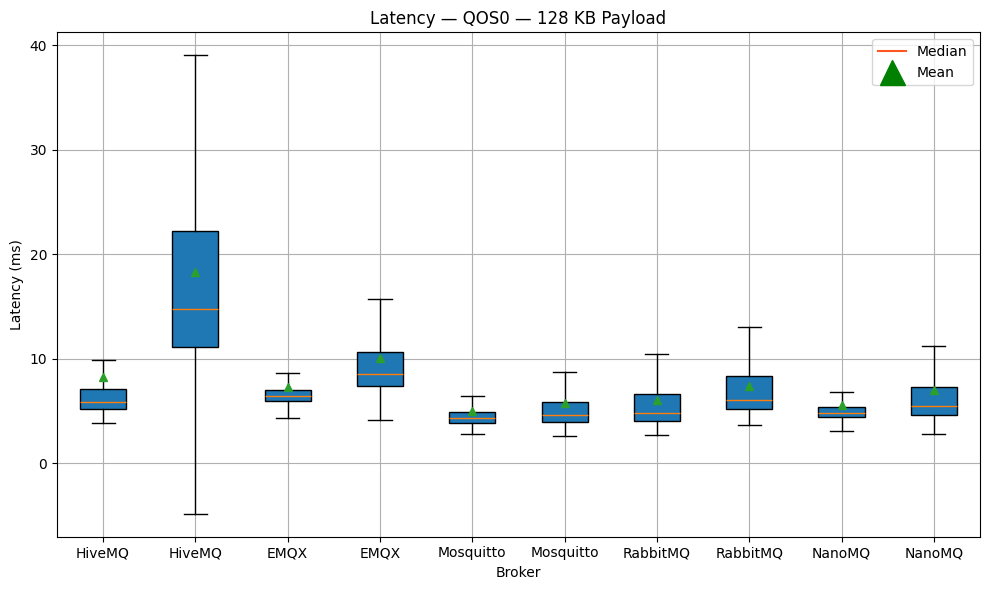

In [7]:
# Latency boxplot — one figure per QoS per payload size
for qos in qoss:
    for ps in _ps_values:
        data_ps = np_array_global[(np_array_global['qos'] == qos) & (np_array_global['payload_size'] == ps)]
        latency_data = []
        labels = []
        for aut in auts:
            data = data_ps[data_ps['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showfliers=False, showmeans=True)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency — {qos.upper()} — {_ps_label(ps)} Payload')
        lmedian = Line2D([], [], color="#FF5722", label="Median", markersize=18)
        green_triangle = Line2D([], [], color='green', marker='^', linestyle='None', markersize=18, label='Mean')
        ax.legend(handles=[lmedian, green_triangle], loc="upper right", ncol=1, fontsize=10)
        plt.grid(True)
        plt.show()


# Load Resource Usage Data

In [8]:
%load_ext autoreload
%autoreload 2

stats_dtype = [("aut", "U32"), ("qos", "U8"),
             ("name", "U64"), ("cpu", "f8"), ("mem_percent", "f8"),("pids", "i4"),
             ("net_io_received", "f8"), ("net_io_received_unit", "U4"),
             ("net_io_transmitted", "f8"), ("net_io_transmitted_unit", "U4"),
             ("block_io_read", "f8"), ("block_io_read_unit", "U4"),
             ("block_io_written", "f8"), ("block_io_written_unit", "U4"), ("entry_id","i4")]

resource_use_vm1 = np.empty(0, dtype=stats_dtype)

def _find_stats_file(aut: str, qos: str):
    import glob as _glob
    # 1. Legacy: subscriber/logs/{aut}/{qos}/stats*
    legacy_prefix = os.path.join(subscriber_logs, aut, qos)
    legacy_file = logs_parser.get_stat_log_file(legacy_prefix)
    if legacy_file:
        return os.path.join(legacy_prefix, legacy_file)
    # 2. AUT0: aut label is aut0_<broker>_<size>
    parts = aut.split("_")
    if len(parts) >= 3 and parts[0] == "aut0":
        broker = parts[1]
        size   = "_".join(parts[2:])
        results_root = os.path.join(cwd, "..", "results")
        # Flat layout: results/<size>/<broker>_<size>_<qos>_docker_stats.txt
        flat = os.path.join(results_root, size, f"{broker}_{size}_{qos}_docker_stats.txt")
        if os.path.isfile(flat):
            return flat
        # Structured layout: results/<broker>/<size>/<qos>/metrics_docker_stats.txt
        structured = os.path.join(results_root, broker, size, qos, "metrics_docker_stats.txt")
        if os.path.isfile(structured):
            return structured
        # Glob fallback: any *broker*qos*docker_stats* file
        for m in _glob.glob(os.path.join(results_root, "**", f"*{broker}*{qos}*docker_stats*"), recursive=True):
            return m
        # Last resort: shared docker_stats.txt (legacy bug — all brokers wrote to same file)
        shared = os.path.join(results_root, size, "docker_stats.txt")
        if os.path.isfile(shared):
            return shared
    return None

for aut in auts:
    for qos in qoss:
        stats_path = _find_stats_file(aut, qos)
        if stats_path is None:
            print(f"  [warn] No docker stats file for {aut}/{qos}, skipping.")
            continue
        print(f"  Loading stats: {stats_path}")
        raw_data = logs_parser.get_stats_logs(stats_path)
        np1 = logs_parser.get_resources_np_array(raw_data, aut, qos)
        resource_use_vm1 = np.concatenate([resource_use_vm1, np1.astype(stats_dtype)])


# VM2 (transformer) does not exist in AUT0; initialise empty so downstream cells do not crash
resource_use_vm2 = np.empty(0, dtype=stats_dtype)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Loading stats: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../results/125kb/hivemq_125kb_qos0_docker_stats.txt
Loaded 39800 entries from 4987 groups of log entries and discarded 0 invalid entries from: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../results/125kb/hivemq_125kb_qos0_docker_stats.txt.
  Loading stats: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../results/35kb_fixed/hivemq_35kb_qos0_docker_stats.txt
Loaded 41772 entries from 5294 groups of log entries and discarded 0 invalid entries from: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../results/35kb_fixed/hivemq_35kb_qos0_docker_stats.txt.
  Loading stats: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../results/125kb/emqx_125kb_qos0_docker_stats.txt
Loaded 40143 entries from 5031 groups of log entries and discarded 8 invalid entries from: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../results/125

## Plot Resource Usage for Host Machine 1 Benchmark Components

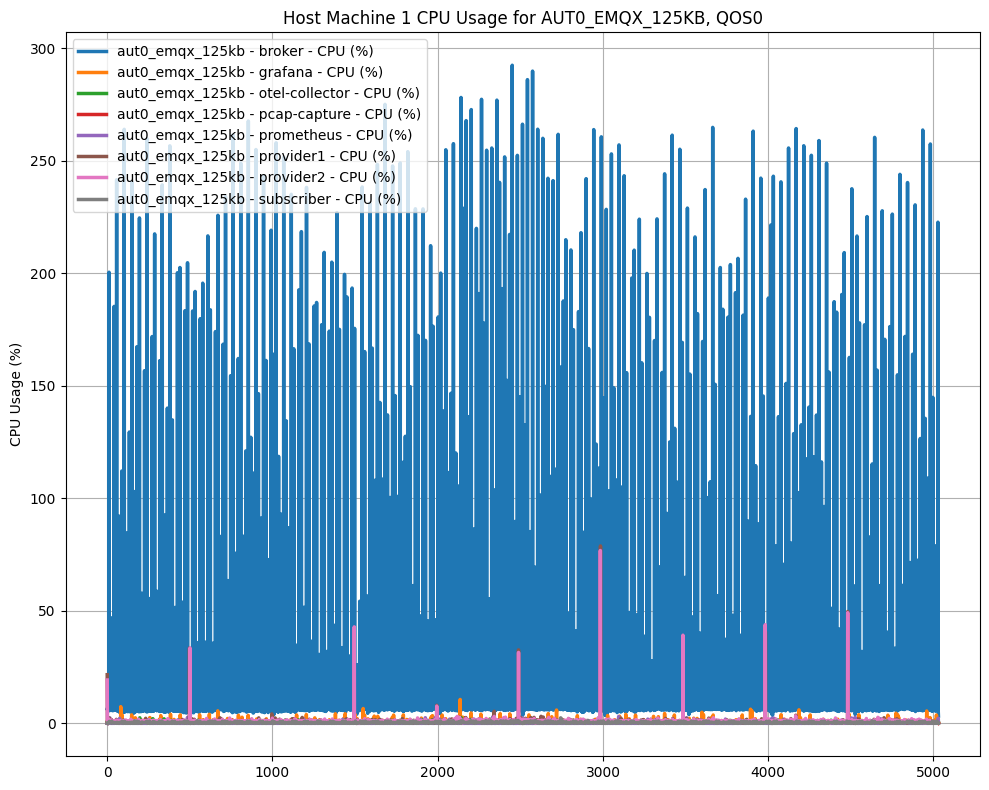

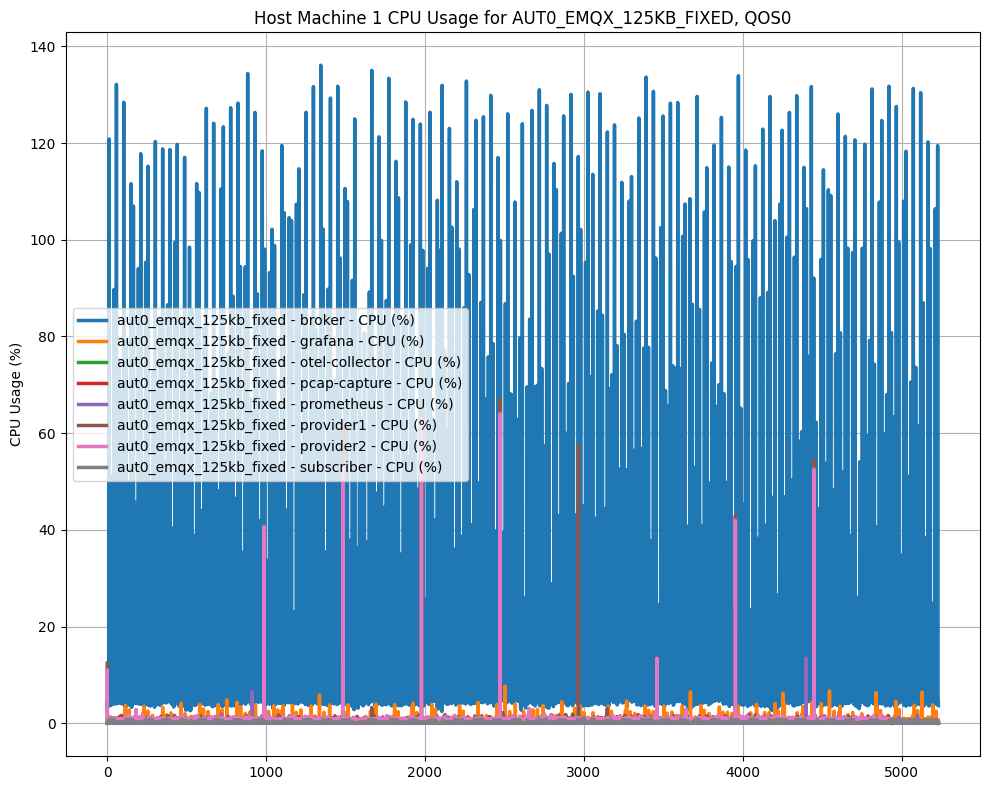

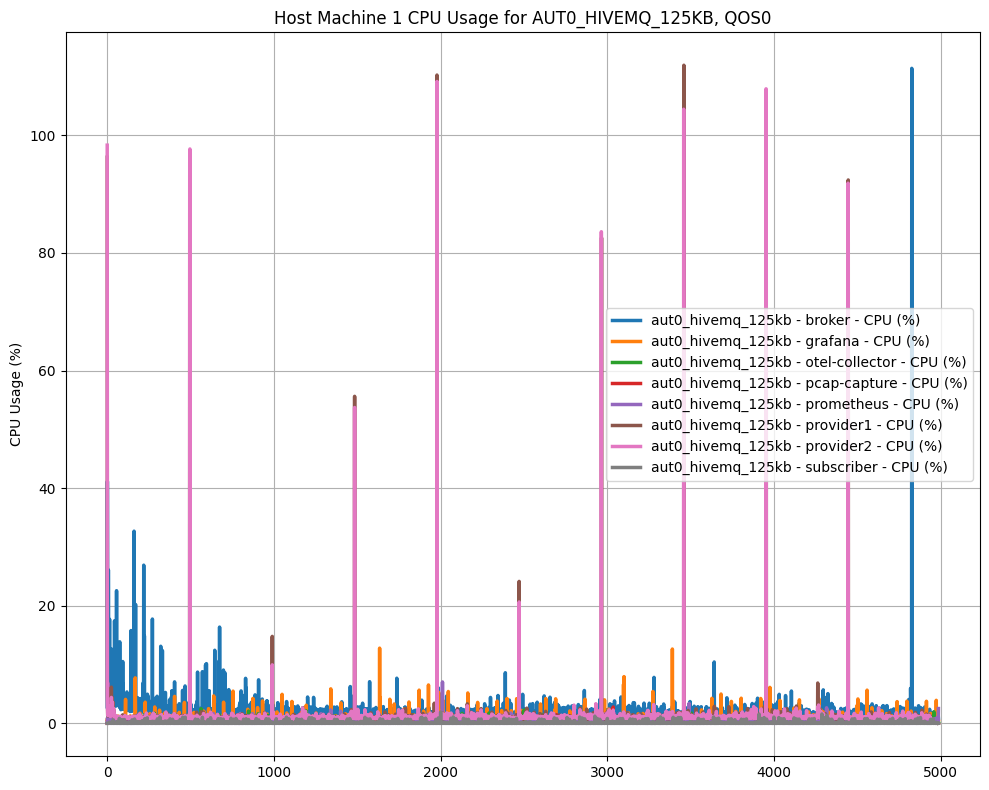

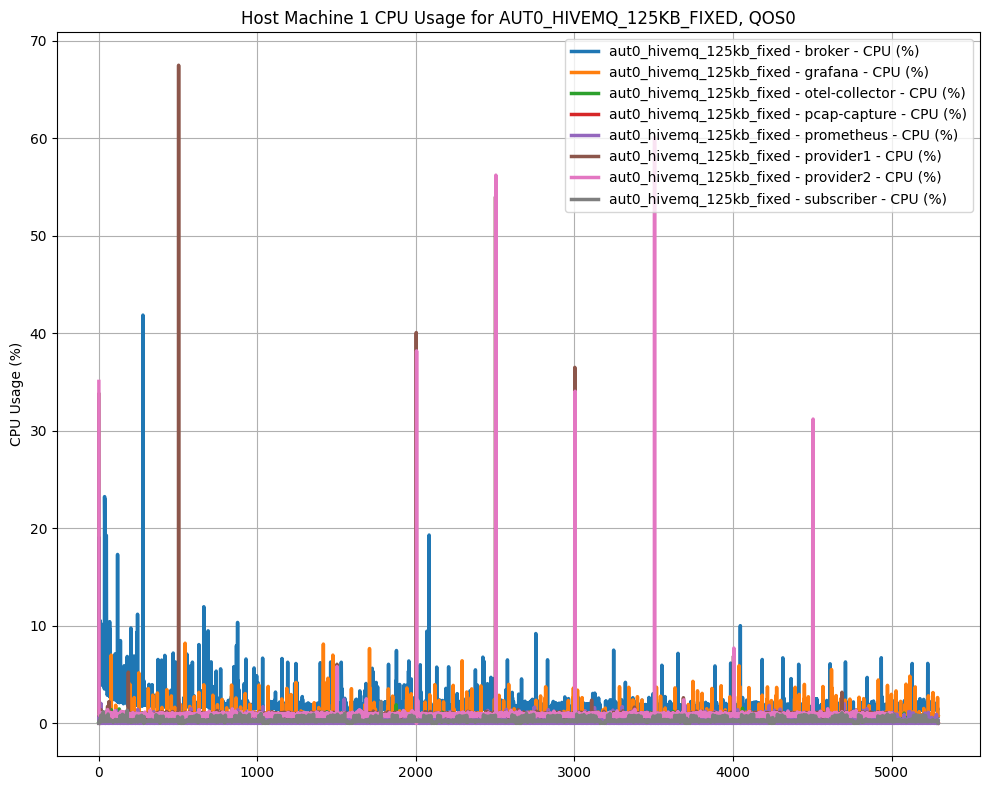

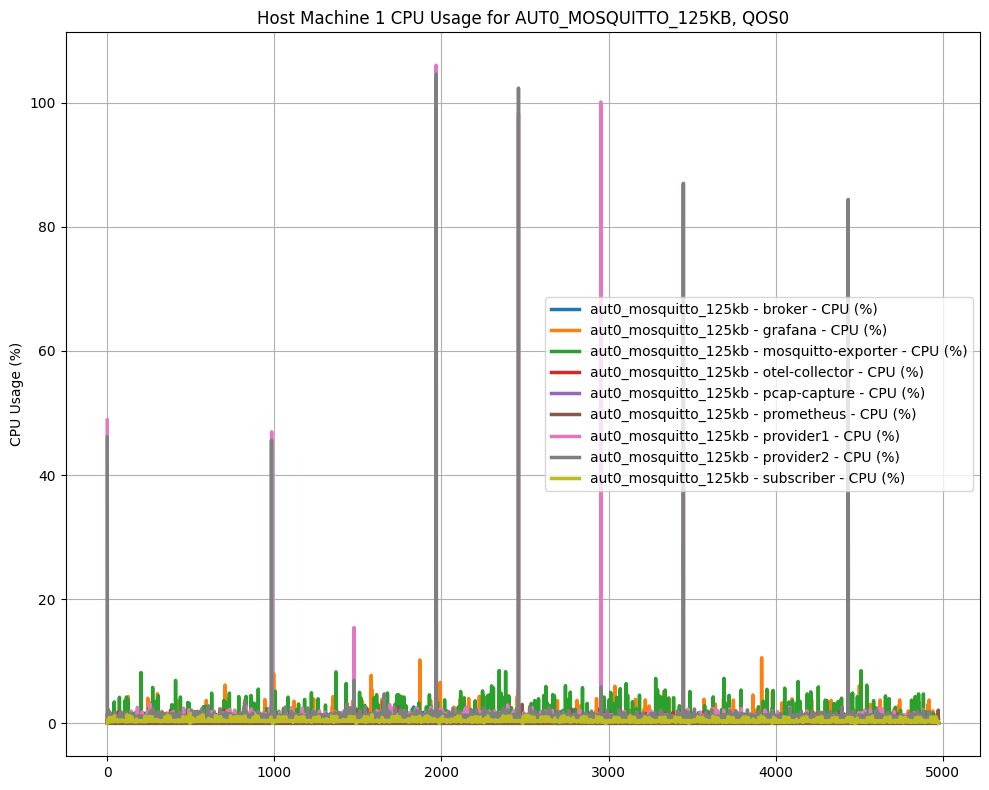

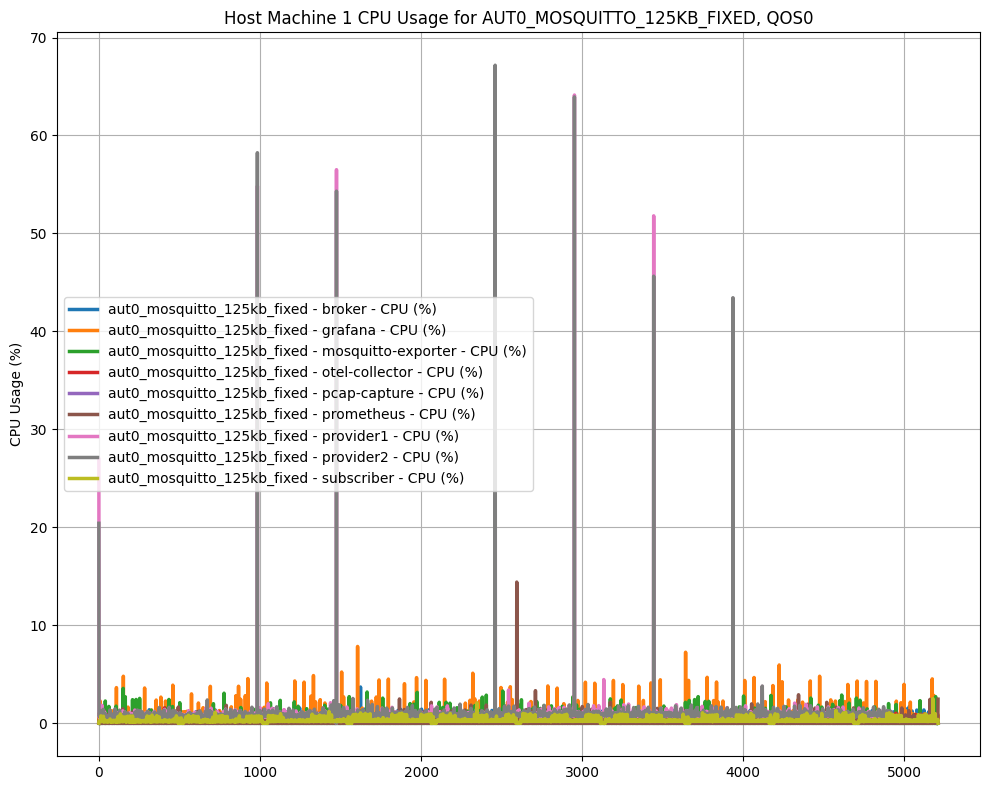

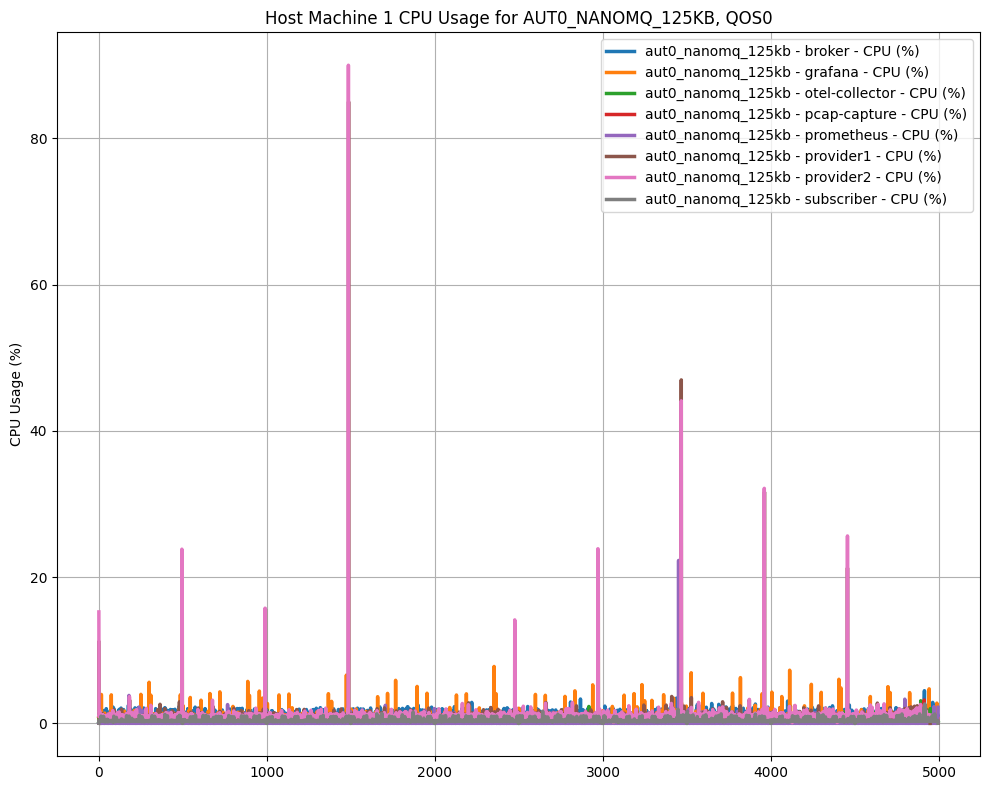

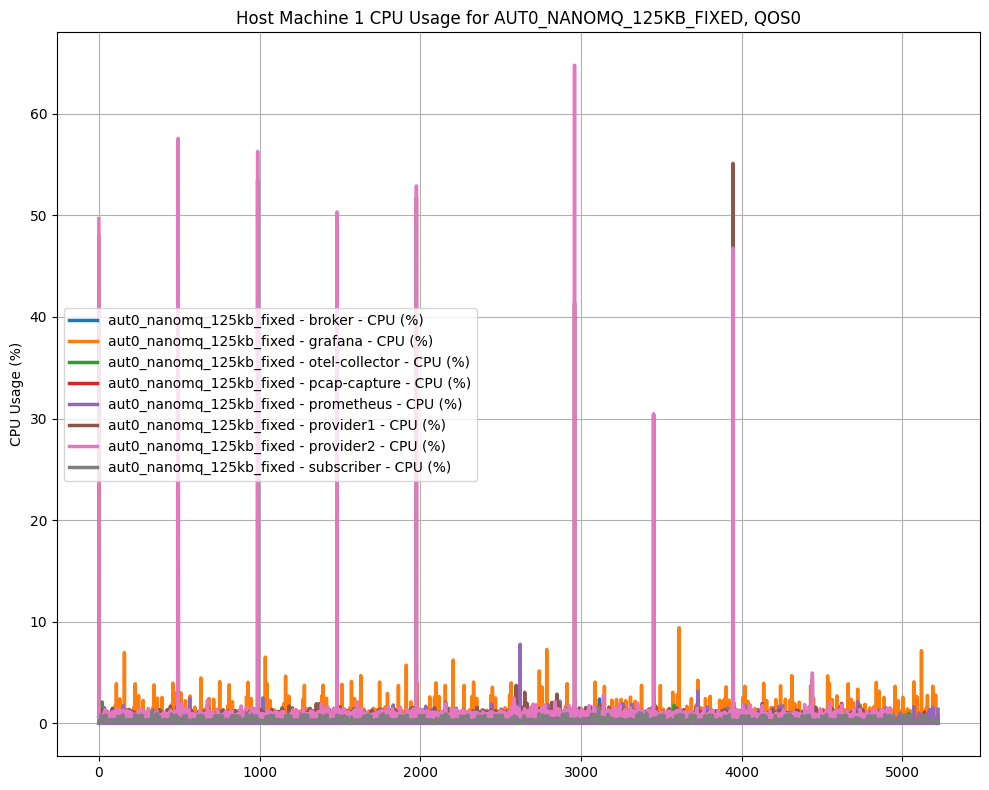

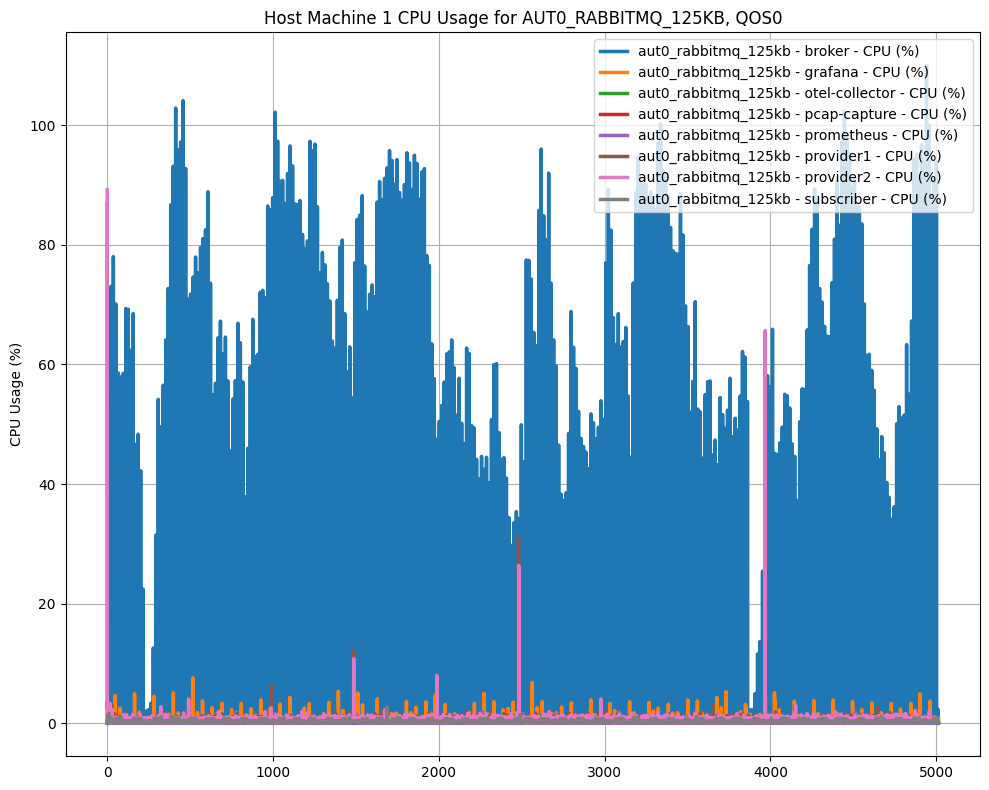

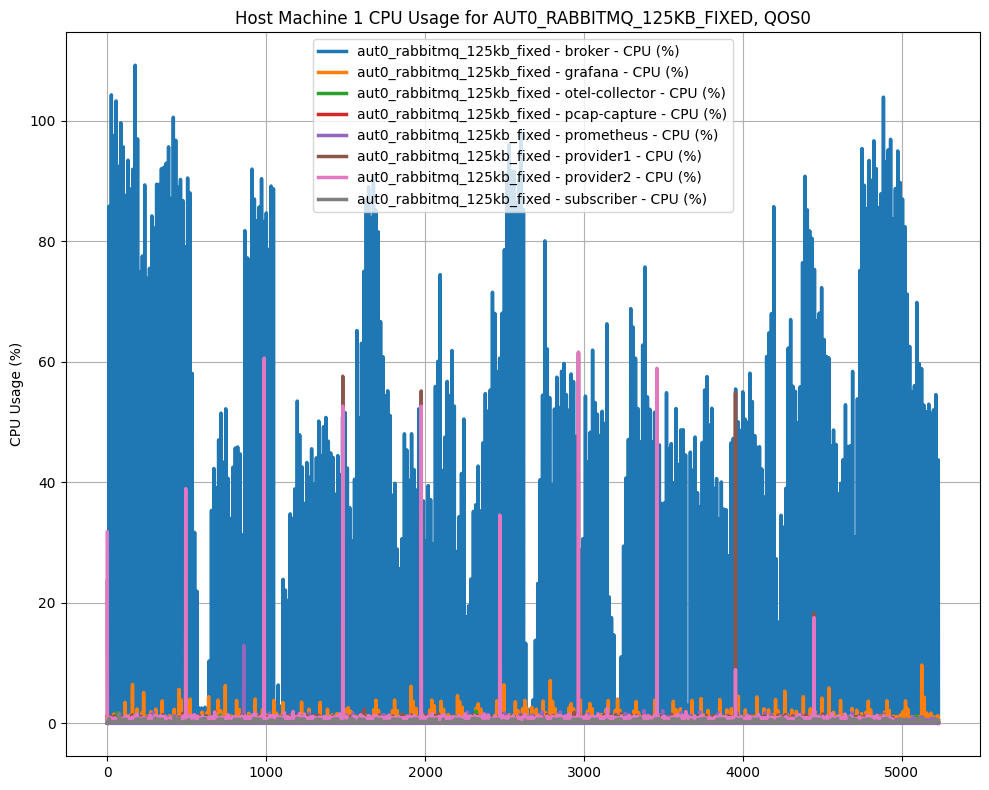

In [9]:
# Get unique pairs of 'aut' and 'name'
unique_aut_qos = np.unique(resource_use_vm1[['aut', 'qos']])

for aut, qos in unique_aut_qos:
    filtered_data = resource_use_vm1[(resource_use_vm1['aut'] == aut) & (resource_use_vm1['qos'] == qos)]

    # Find unique names within the filtered data
    unique_names = np.unique(filtered_data['name'])

    # Plot data
    plt.figure(figsize=(10, 8))

    for name in unique_names:
        # Filter data for each unique name within the current 'aut' and 'qos' combination
        name_filtered_data = filtered_data[filtered_data['name'] == name]
      
        # Use the indices of the subset for x-axis
        indices = np.arange(len(name_filtered_data))
        
        plt.plot(indices, name_filtered_data['cpu'], label=f'{aut} - {name} - CPU (%)', linewidth=2.5)
        # plt.plot(time_series, name_filtered_data['mem_percent'], label=f'{aut} - {name} - Mem (%)', linewidth=2.5)
    
    # plt.xlabel('Index')
    plt.ylabel('CPU Usage (%)')
    plt.title(f'Host Machine 1 CPU Usage for {aut.upper()}, {qos.upper()}')
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

/tmp/ipykernel_2830/2670678150.py:49: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.savefig('detailed_cpu_host_machine_1.png', format='png')
/home/heilo/benchmark/mqtt_benchmark/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


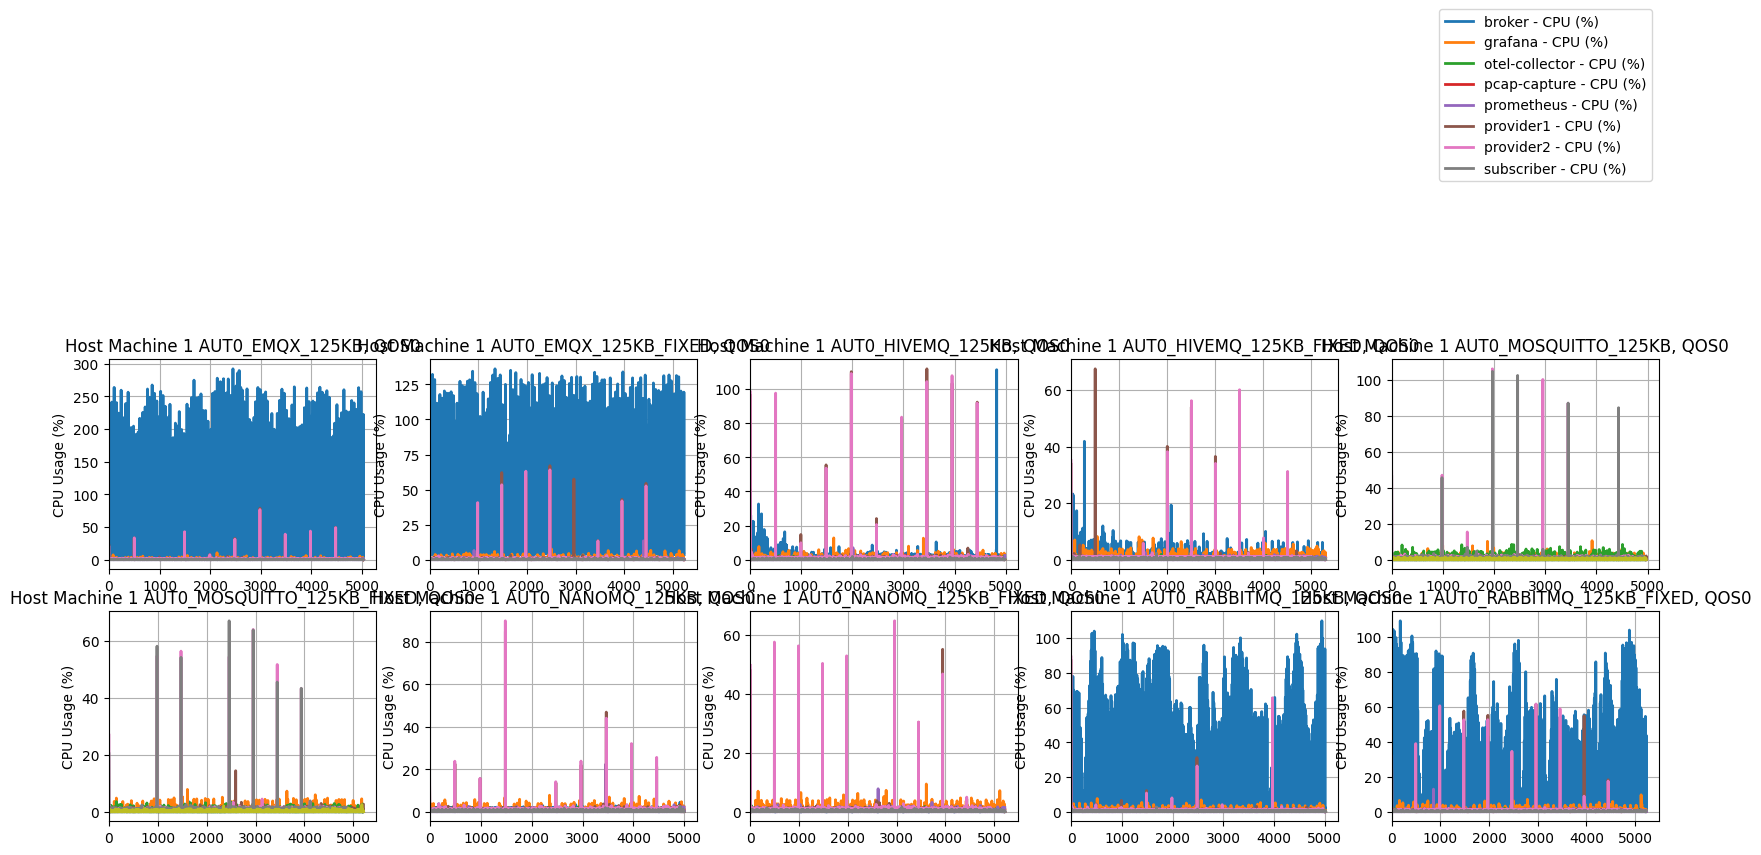

In [10]:
from math import ceil as _ceil
# Get unique pairs of 'aut' and 'name'
unique_aut_qos = np.unique(resource_use_vm1[['aut', 'qos']])

# Determine the grid size based on the number of unique pairs
num_plots = len(unique_aut_qos)
ncols = min(num_plots, 5)
nrows = _ceil(num_plots / ncols)

# Create subplots - sized dynamically to fit all experiments
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3))

# Flatten the axes array to easily iterate over
axes_flat = np.array(axes).flatten()

# Plot each unique combination in a separate subplot
for i, (aut, qos) in enumerate(unique_aut_qos):
    filtered_data = resource_use_vm1[(resource_use_vm1['aut'] == aut) & (resource_use_vm1['qos'] == qos)]

    # Find unique names within the filtered data
    unique_names = np.unique(filtered_data['name'])

    # Get the corresponding subplot axes
    ax = axes_flat[i]

    for name in unique_names:
        # Filter data for each unique name within the current 'aut' and 'qos' combination
        name_filtered_data = filtered_data[filtered_data['name'] == name]
      
        # Use the indices of the subset for x-axis
        indices = np.arange(len(name_filtered_data))

        # Plot cpu usage 
        ax.plot(indices, name_filtered_data['cpu'], label=f'{name} - CPU (%)', linewidth=2)
    
        ax.set_ylabel('CPU Usage (%)')
        ax.set_title(f'Host Machine 1 {aut.upper()}, {qos.upper()}')
        # ax.legend(loc='upper right', bbox_to_anchor=(1, 1))
        # ax.legend(loc='best')
        ax.set_xlim(0)
        ax.grid(True)

plt.legend(loc='upper right', bbox_to_anchor=(1, 3.9))

# Tight layout to adjust subplots
# plt.tight_layout()

# Save the plot
plt.savefig('detailed_cpu_host_machine_1.png', format='png')

# Show the plot
plt.show()

## Memory Usage Host Machine 1

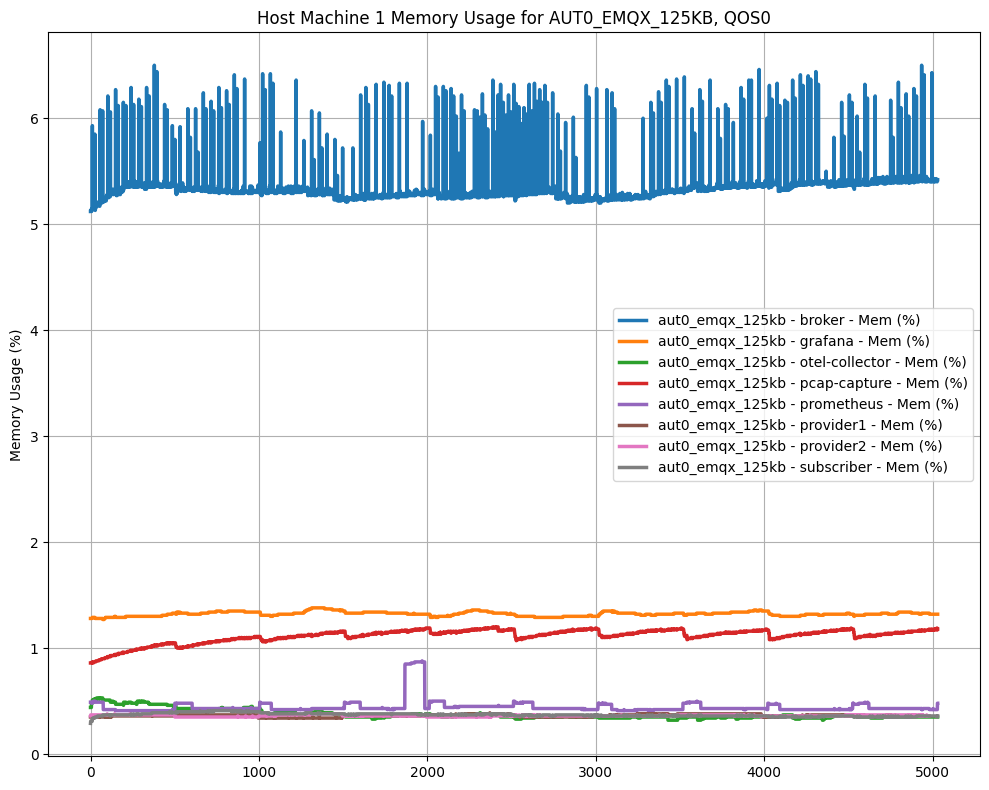

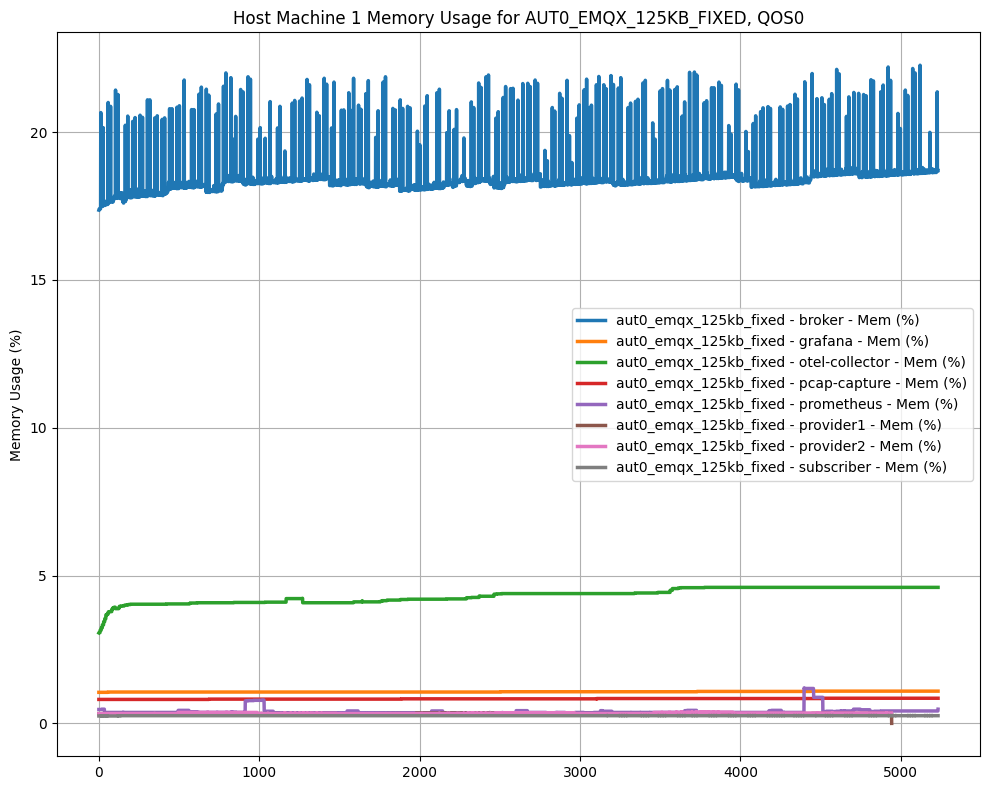

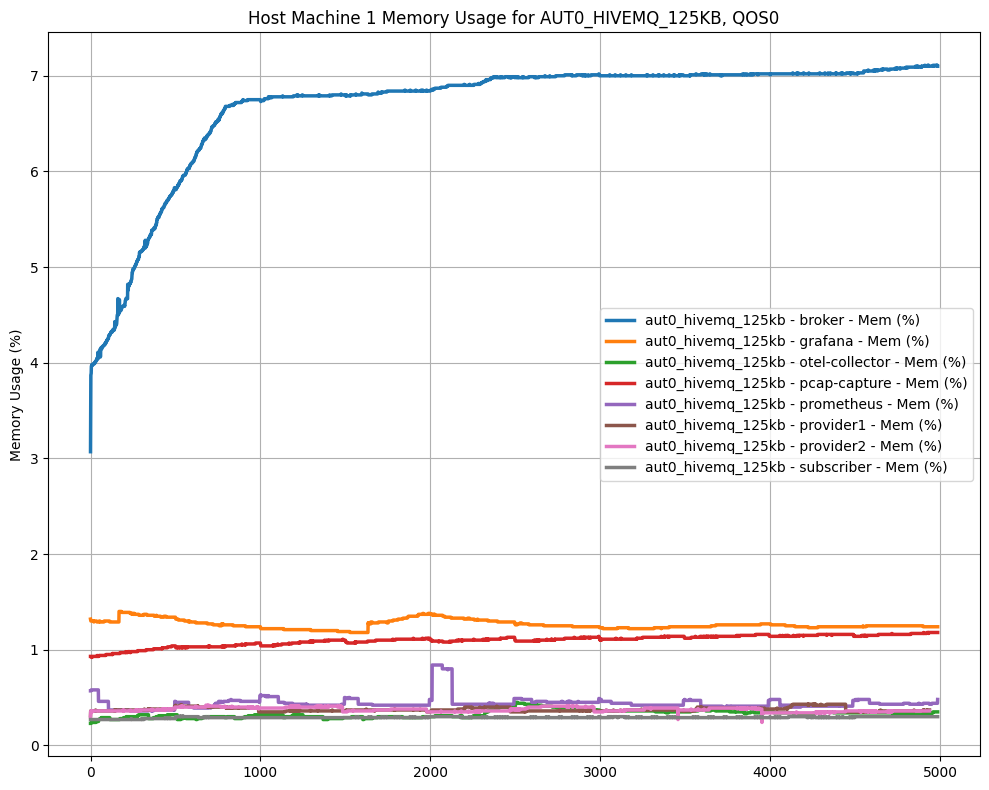

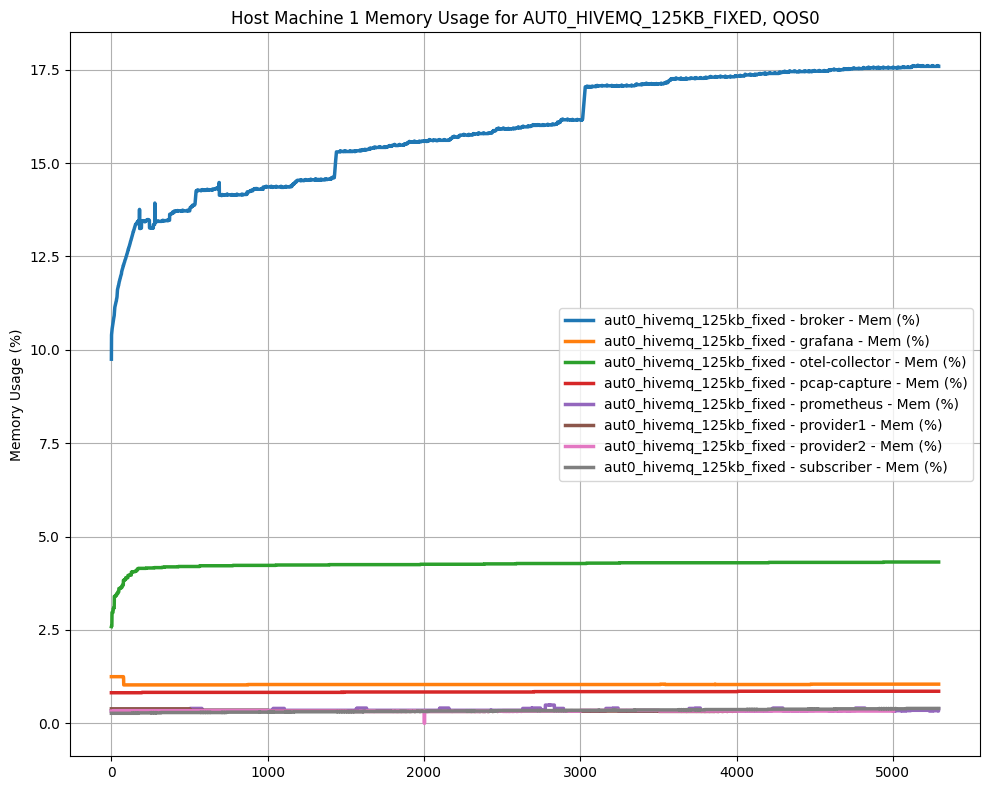

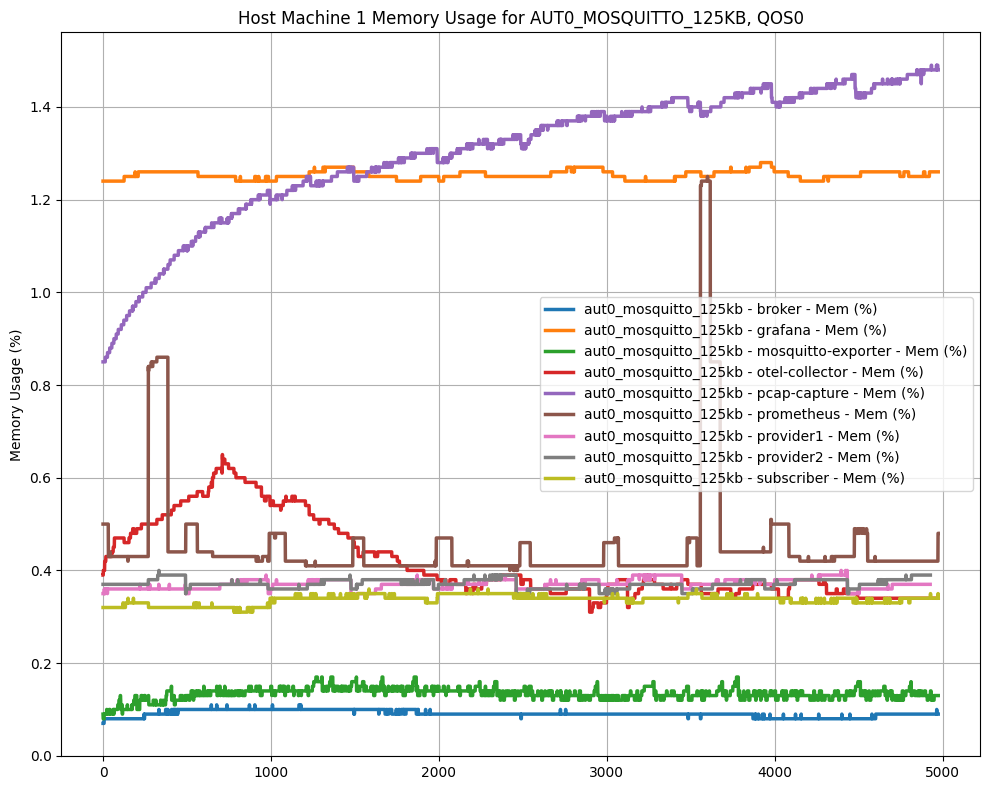

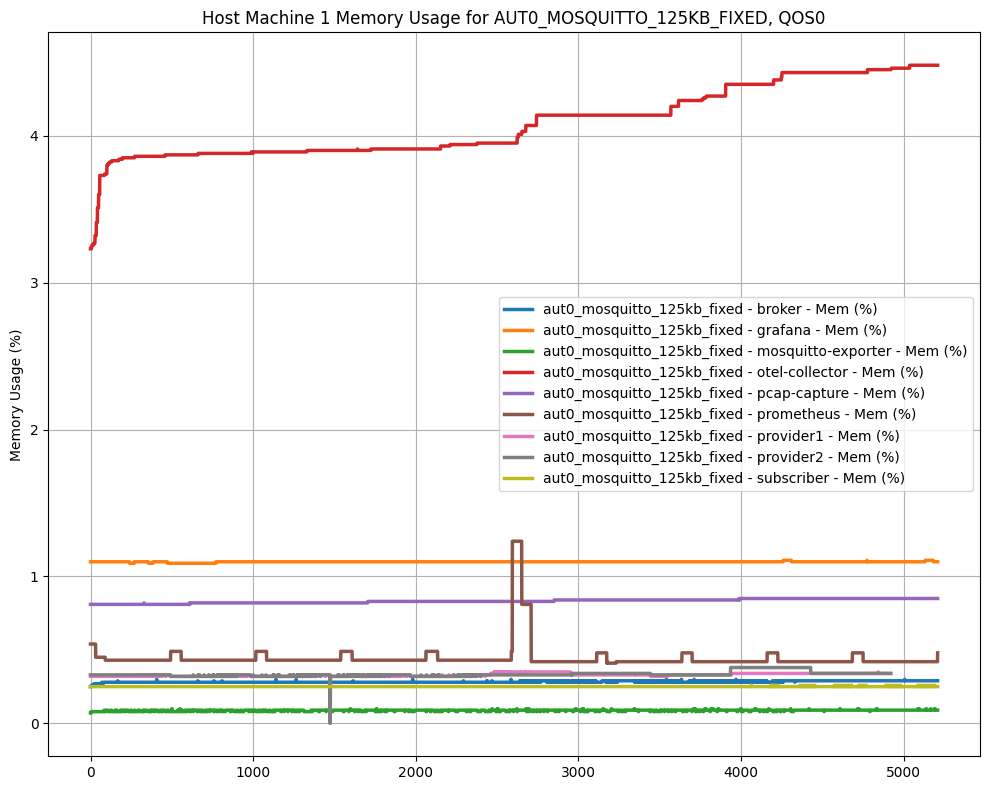

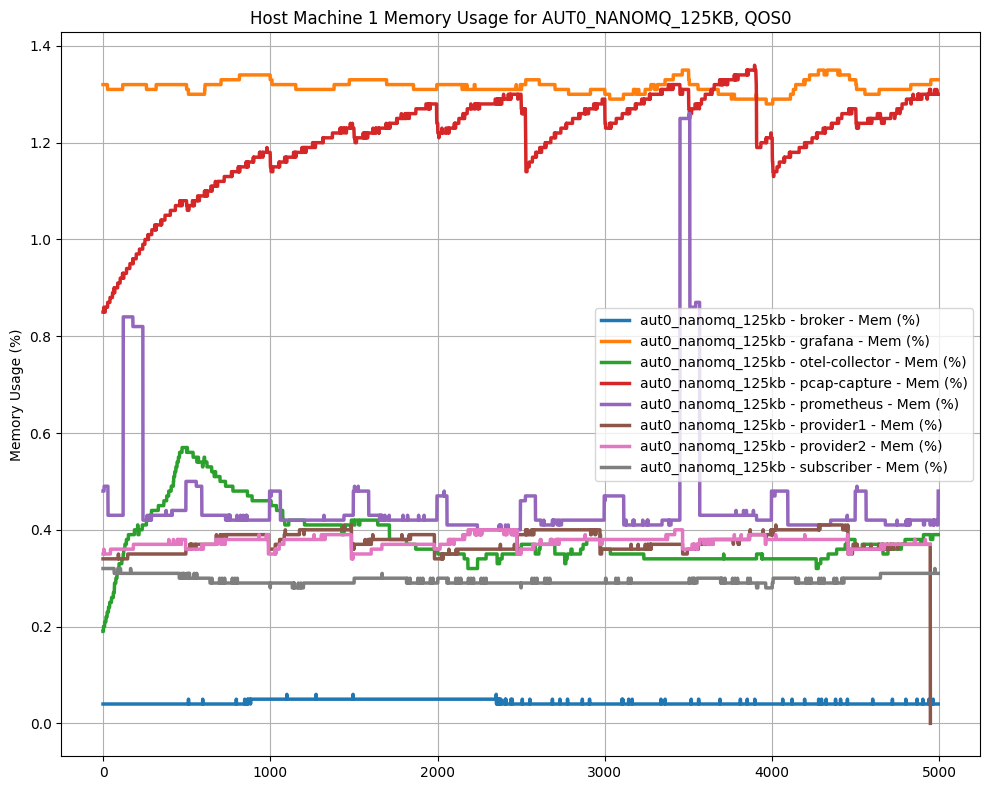

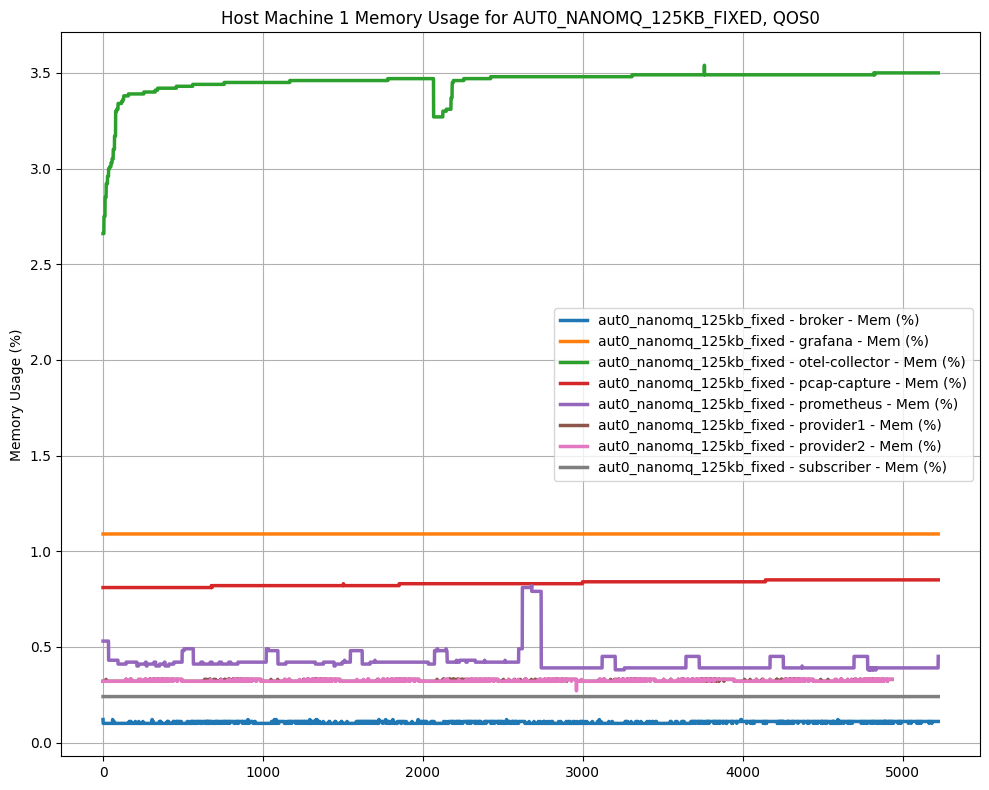

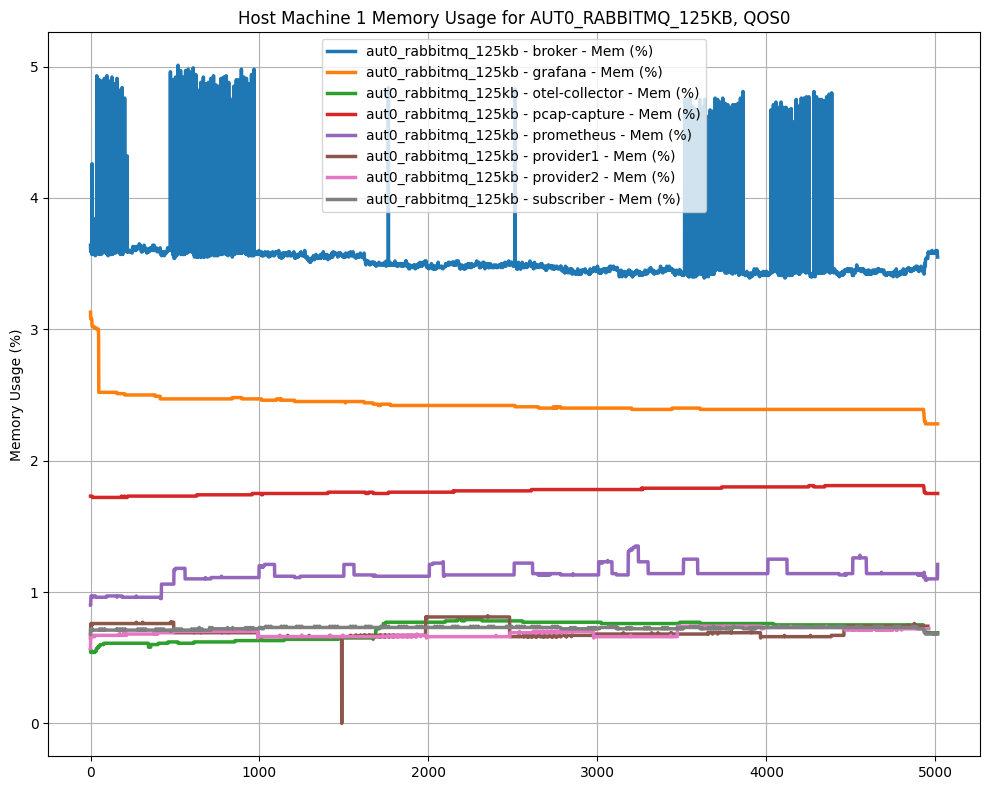

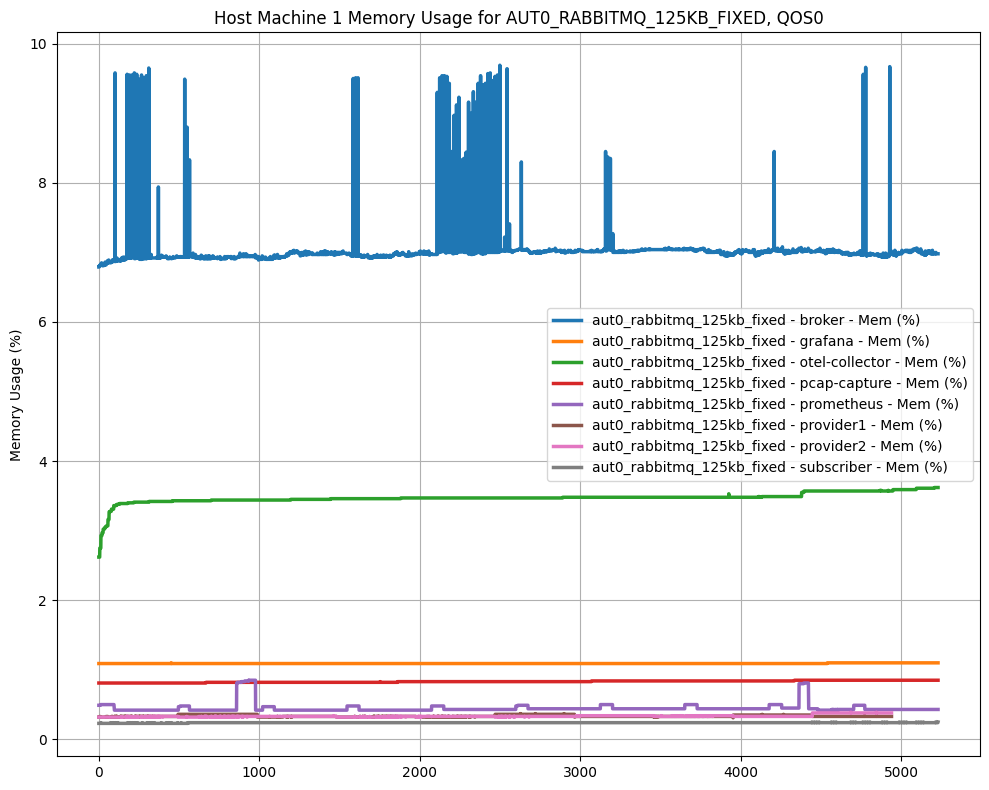

In [11]:
# Get unique pairs of 'aut' and 'name'
unique_aut_qos = np.unique(resource_use_vm1[['aut', 'qos']])

for aut, qos in unique_aut_qos:
    filtered_data = resource_use_vm1[(resource_use_vm1['aut'] == aut) & (resource_use_vm1['qos'] == qos)]

    # Find unique names within the filtered data
    unique_names = np.unique(filtered_data['name'])

    # Plot data
    plt.figure(figsize=(10, 8))

    for name in unique_names:
        # Filter data for each unique name within the current 'aut' and 'qos' combination
        name_filtered_data = filtered_data[filtered_data['name'] == name]
      
        # Use the indices of the subset for x-axis
        indices = np.arange(len(name_filtered_data))
        
        # plt.plot(time_series, name_filtered_data['cpu'], label=f'{aut} - {name} - CPU (%)', linewidth=2.5)
        plt.plot(indices, name_filtered_data['mem_percent'], label=f'{aut} - {name} - Mem (%)', linewidth=2.5)
    
    # plt.xlabel('Index')
    plt.ylabel('Memory Usage (%)')
    plt.title(f'Host Machine 1 Memory Usage for {aut.upper()}, {qos.upper()}')
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

## Plot Resource Usage for Host Machine 2 Benchmark Components

In [12]:
if len(resource_use_vm2) == 0:
    print("[skip] No VM2/transformer stats (not applicable to AUT0 experiments)")
else:
    # Get unique pairs of 'aut' and 'name'
    unique_aut_qos = np.unique(resource_use_vm2[['aut', 'qos']])

    for aut, qos in unique_aut_qos:
        filtered_data = resource_use_vm2[(resource_use_vm2['aut'] == aut) & (resource_use_vm2['qos'] == qos)]

        # Find unique names within the filtered data
        unique_names = np.unique(filtered_data['name'])

        # Plot data
        plt.figure(figsize=(10, 8))

        for name in unique_names:
            # Filter data for each unique name within the current 'aut' and 'qos' combination
            name_filtered_data = filtered_data[filtered_data['name'] == name]
          
            # Use the indices of the subset for x-axis
            indices = np.arange(len(name_filtered_data))
            
            plt.plot(indices, name_filtered_data['cpu'], label=f'{aut} - {name} - CPU (%)', linewidth=2.5)
            # plt.plot(time_series, name_filtered_data['mem_percent'], label=f'{aut} - {name} - Mem (%)', linewidth=2.5)
        
        # plt.xlabel('Index')
        plt.ylabel('CPU Usage (%)')
        plt.title(f'Host Machine 2 CPU Usage for {aut.upper()}, {qos.upper()}')
        plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()


[skip] No VM2/transformer stats (not applicable to AUT0 experiments)


## Source Brokers Resource Usage (Host Machine 2)

In [13]:
if len(resource_use_vm2) == 0:
    print("[skip] No VM2/transformer stats (not applicable to AUT0 experiments)")
else:
    # Filter the data where 'name' contains "ingestion-hivemq-broker"
    filtered_resource_use = resource_use_vm2[np.char.find(resource_use_vm2['name'], 'ingestion-hivemq-broker') != -1]

    # Get unique pairs of 'aut' and 'qos'
    unique_aut_qos = np.unique(filtered_resource_use[['aut', 'qos']], axis=0)

    # Create subplots (3x3)
    num_plots = len(unique_aut_qos)
    ncols = min(num_plots, 5)
    nrows = -(-num_plots // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3))
    axes_flat = np.array(axes).flatten()

    # Iterate through unique pairs and plot the data
    for i, (aut, qos) in enumerate(unique_aut_qos):
        # Filter data for this combination
        filtered_data = filtered_resource_use[(filtered_resource_use['aut'] == aut) & (filtered_resource_use['qos'] == qos)]

        # Get the corresponding subplot axis
        ax = axes_flat[i]

        # Find unique names within the filtered data
        unique_names = np.unique(filtered_data['name'])
        for name in unique_names:
            # Filter data for this name
            name_filtered_data = filtered_data[filtered_data['name'] == name]

            # Use indices for x-axis
            indices = np.arange(len(name_filtered_data))

            # Plot CPU usage
            ax.plot(indices, name_filtered_data['cpu'], label=f'{name} CPU (%)', linewidth=2)

        # Set labels, title, and grid
        ax.set_ylabel('CPU Usage (%)')
        ax.set_title(f'Host Machine 2 {aut.upper()}, {qos.upper()}')
        # ax.legend(loc='best')
        ax.grid(True)

    plt.legend(loc='upper right', bbox_to_anchor=(1, 3.9))

    # Adjust layout
    # plt.tight_layout()

    # Save plot
    plt.savefig('grid_cpu_host_machine_2_source_brokers.png', format='png')

    # Show plot
    plt.show()


[skip] No VM2/transformer stats (not applicable to AUT0 experiments)


## Memory Usage Host Machine 2

In [14]:
if len(resource_use_vm2) == 0:
    print("[skip] No VM2/transformer stats (not applicable to AUT0 experiments)")
else:
    # Get unique pairs of 'aut' and 'name'
    unique_aut_qos = np.unique(resource_use_vm2[['aut', 'qos']])

    for aut, qos in unique_aut_qos:
        filtered_data = resource_use_vm2[(resource_use_vm2['aut'] == aut) & (resource_use_vm2['qos'] == qos)]

        # Find unique names within the filtered data
        unique_names = np.unique(filtered_data['name'])

        # Plot data
        plt.figure(figsize=(10, 8))

        for name in unique_names:
            # Filter data for each unique name within the current 'aut' and 'qos' combination
            name_filtered_data = filtered_data[filtered_data['name'] == name]
          
            # Use the index as the time series
            time_series = np.arange(len(name_filtered_data))
            
            # plt.plot(time_series, name_filtered_data['cpu'], label=f'{aut} - {name} - CPU (%)', linewidth=2.5)
            plt.plot(time_series, name_filtered_data['mem_percent'], label=f'{aut} - {name} - Mem (%)', linewidth=2.5)
        
        # plt.xlabel('Index')
        plt.ylabel('Memory Usage (%)')
        plt.title(f'Host Machine 2 Memory Usage for {aut.upper()}, {qos.upper()}')
        plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()


[skip] No VM2/transformer stats (not applicable to AUT0 experiments)


## Cumulative Plot Resource Usage for QoS 0 for Host Machine 2

In [15]:
if len(resource_use_vm2) == 0:
    print("[skip] No VM2/transformer stats (not applicable to AUT0 experiments)")
else:
    # Create a combined key and use np.unique to get unique combinations and inverse indices
    keys = np.array(resource_use_vm2[['aut', 'qos', 'entry_id']].tolist())
    unique_keys, inverse_indices = np.unique(keys, axis=0, return_inverse=True)

    # Sum cpu field based on inverse indices
    cpu_sums = np.zeros(len(unique_keys))
    np.add.at(cpu_sums, inverse_indices, resource_use_vm2['cpu'])

    # Create a result array merging unique_keys and cpu_sums
    result = np.rec.fromarrays([unique_keys[:, 0], unique_keys[:, 1], unique_keys[:, 2], cpu_sums], 
                               names=('aut', 'qos', 'entry_id', 'cpu'))

    # Create a unique set of aut and qos combinations for the legend
    unique_aut_qos = np.unique(result[['aut', 'qos']], axis=0)

    # Plot each unique combination
    for aut, qos in unique_aut_qos:
        # Plotting results
        plt.figure(figsize=(10, 8))
        mask = (result['aut'] == aut) & (result['qos'] == qos)
        subset = result[mask]

        # Determine the y-axis limit
        y_max = max(100, ceil(np.max(subset['cpu']))+5)

        print(f'{aut.upper()} and {qos.upper()} max: {y_max}')

        # Use the indices of the subset for x-axis
        indices = np.arange(len(subset))
        
        plt.plot(indices, subset['cpu'], label=f'{aut}, {qos}', linewidth=2.0)

        plt.ylabel('Total CPU (%)')
        plt.title(f'Host Machine 2 Total CPU Usage for {aut.upper()}, {qos.upper()}')
        # plt.legend(loc='best')
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.ylim(0, y_max)  # Set the y-axis limits from 0 to 100 or the max
        plt.xlim(0)
        plt.tight_layout()
        plt.show()


[skip] No VM2/transformer stats (not applicable to AUT0 experiments)


### Arranged Cumulative Plots

In [16]:
if len(resource_use_vm2) == 0:
    print("[skip] No VM2/transformer stats (not applicable to AUT0 experiments)")
else:
    # Create a combined key and use np.unique to get unique combinations and inverse indices
    keys = np.array(resource_use_vm2[['aut', 'qos', 'entry_id']].tolist())
    unique_keys, inverse_indices = np.unique(keys, axis=0, return_inverse=True)

    # Sum cpu field based on inverse indices
    cpu_sums = np.zeros(len(unique_keys))
    np.add.at(cpu_sums, inverse_indices, resource_use_vm2['cpu'])

    # Create a result array merging unique_keys and cpu_sums
    result = np.rec.fromarrays([unique_keys[:, 0], unique_keys[:, 1], unique_keys[:, 2], cpu_sums], 
                               names=('aut', 'qos', 'entry_id', 'cpu'))

    # Create a unique set of aut and qos combinations for the legend
    unique_aut_qos = np.unique(result[['aut', 'qos']], axis=0)

    # Calculate the total number of unique combinations
    num_plots = len(unique_aut_qos)

    # Create subplots - adjust nrows and ncols to fit your data
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 8))

    # Flatten the axes array to easily iterate over
    axes_flat = axes.flatten()

    # Plot each unique combination in a separate subplot
    for i, (aut, qos) in enumerate(unique_aut_qos):
        # Plotting results
        # plt.figure(figsize=(10, 8))
        mask = (result['aut'] == aut) & (result['qos'] == qos)
        subset = result[mask]

        # Determine the y-axis limit
        y_max = max(100, ceil(np.max(subset['cpu']))+5)

        # Use the indices of the subset for x-axis
        indices = np.arange(len(subset))

        ax = axes_flat[i]
        ax.plot(indices, subset['cpu'], label=f'{aut}, {qos}', linewidth=2.0)
        ax.set_ylim(0, y_max) # Set the y-axis limits from 0 to 100 or the max
        ax.set_xlim(0)
        ax.set_title(f'Host Machine 2 {aut.upper()}, {qos.upper()}')
        ax.set_ylabel('Total CPU (%)')
        # ax.legend(loc='best')
        ax.grid(True)

    # Tight layout to adjust subplots
    plt.tight_layout()

    # Save the figure to a PDF file
    plt.savefig('cpu_grid_host_machine_2.png', format='png')
        
    plt.show()


[skip] No VM2/transformer stats (not applicable to AUT0 experiments)


# Build Sub Sets
Build the following sub-sets for each benchmark setup (AUT-QoS), based on filters applied to different columns of data
1. Per each repetion in the setup execution (10);
2. Per data Provider (2);
3. Per Gateway/Publisher (3);
4. Combination among the previous sets

In [17]:
# Auto-discover gateways and provider topic prefixes from loaded data if not set.
if not gateways:
    gateways = sorted(np.unique(np_array_global['gateway']).tolist())
    print(f'Auto-discovered gateways: {gateways}')

if not providers_tp:
    # Unique first path segment of each topic (e.g. 'site1/gateway1' or 'site1/provider1')
    _tp_set = set()
    for t in np_array_global['topic']:
        parts = t.split('/')
        if len(parts) >= 2:
            _tp_set.add(parts[0] + '/' + parts[1])
    providers_tp = sorted(_tp_set)
    print(f'Auto-discovered topic prefixes: {providers_tp}')

# Build execution bounds from publisher timestamps
execs_bounds = dict()
for aut in auts:
    for qos in qoss:
        aut_pub_log_folder = os.path.join(publishers_logs, aut, qos)
        if not os.path.isdir(aut_pub_log_folder) or not os.listdir(aut_pub_log_folder):
            continue
        dates = logs_parser.get_pub_exec_datetimes(aut_pub_log_folder)
        execs_bounds['.'.join((aut, qos))] = logs_parser.get_execs_bounds(dates)

# Subset by topic prefix (providers_sets) and gateway (gateways_sets)
providers_sets = [
    np_array_global[np.char.startswith(np_array_global['topic'], tp)]
    for tp in providers_tp
]

gateways_sets = []
for gw in gateways:
    subset = np_array_global[np_array_global['gateway'] == gw]
    gateways_sets.append(subset)

assert len(providers_sets) == len(providers_tp)
assert len(gateways_sets) == len(gateways)
print(f'Gateways: {gateways}')
print(f'Topic prefixes: {providers_tp}')

# ── Per-gateway expected message count (derived from publisher logs) ─────────
def _expected_msgs_for_gateway(gateway):
    """Count actual published messages for a gateway from publisher logs.
    Falls back to logs_parser.get_expected_msgs_per_gateway() for AUT1/AUT2.
    gateway: short name like 'gateway1' or dotted name like 'provider1.gateway1'.
    """
    gw_short = gateway.split('.')[-1]          # 'gateway1' from either form
    for aut in auts:
        for qos in qoss:
            pub_dir = os.path.join(publishers_logs, aut, qos)
            if not os.path.isdir(pub_dir):
                continue
            count = 0
            for fname in os.listdir(pub_dir):
                if gw_short in fname:
                    fpath = os.path.join(pub_dir, fname)
                    with open(fpath) as fh:
                        count += sum(1 for line in fh if 'rc: Success' in line)
            if count > 0:
                return count
    # Fallback: use hardcoded constant (AUT1/AUT2 with full NUM_MSG runs)
    return logs_parser.get_expected_msgs_per_gateway(gateway)


Auto-discovered gateways: ['gateway1', 'gateway2']
Auto-discovered topic prefixes: ['site1/gateway1', 'site1/gateway2']
Gateways: ['gateway1', 'gateway2']
Topic prefixes: ['site1/gateway1', 'site1/gateway2']


## Results per Gateway (Sub Set  Grouped by Payload Sizes)

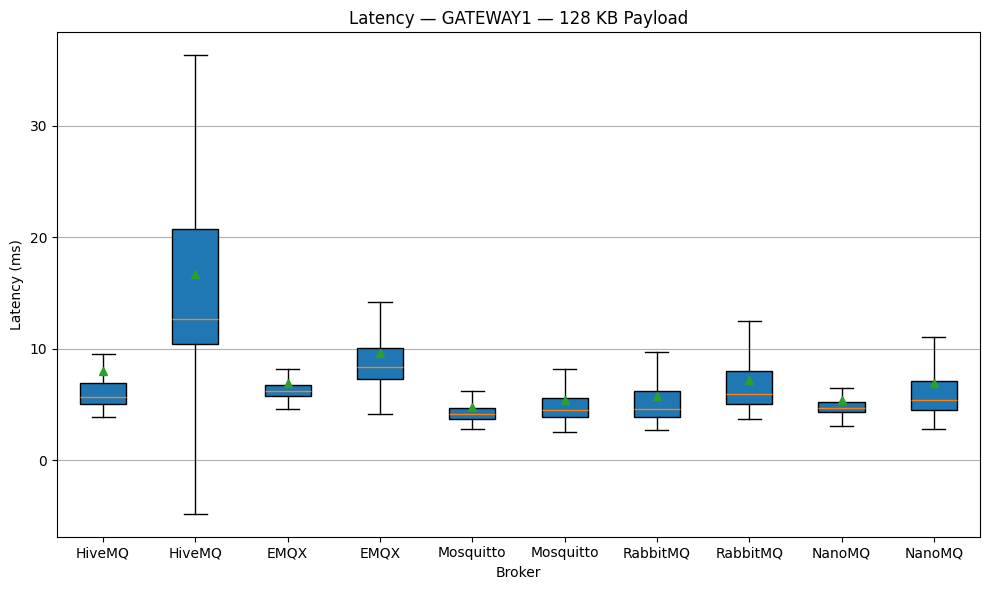

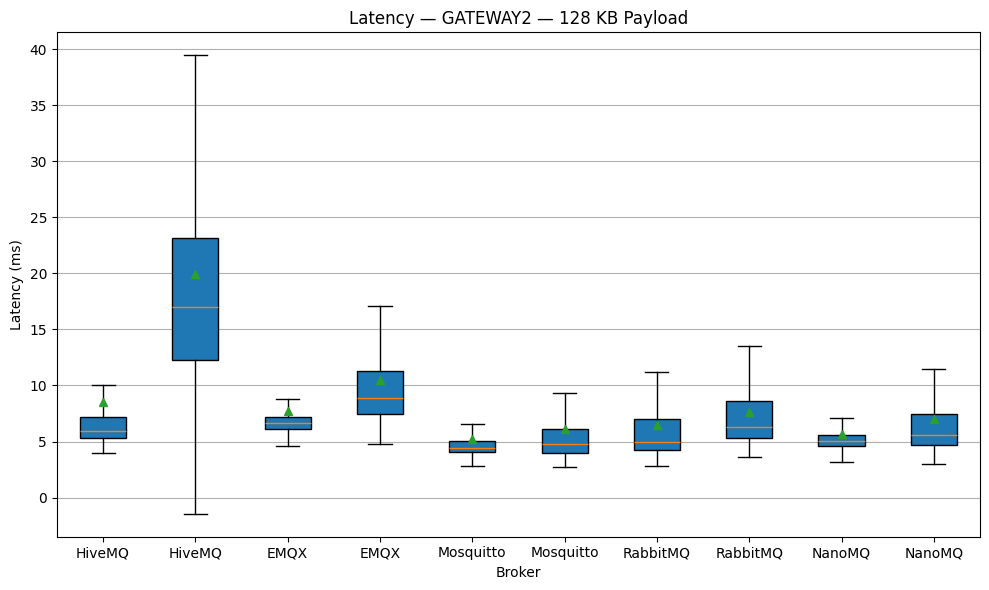

In [18]:
for i, subset in enumerate(gateways_sets):
    gateway = gateways[i]
    for ps in _ps_values:
        ps_subset = subset[subset['payload_size'] == ps]
        latency_data = []
        labels = []
        for aut in auts:
            data = ps_subset[ps_subset['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showfliers=False, showmeans=True)
        ax.yaxis.grid(True)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency — {gateway.upper()} — {_ps_label(ps)} Payload')
        plt.show()


## Figures 4-6: Latency Box Plots for Executions w/ no Significant Loss

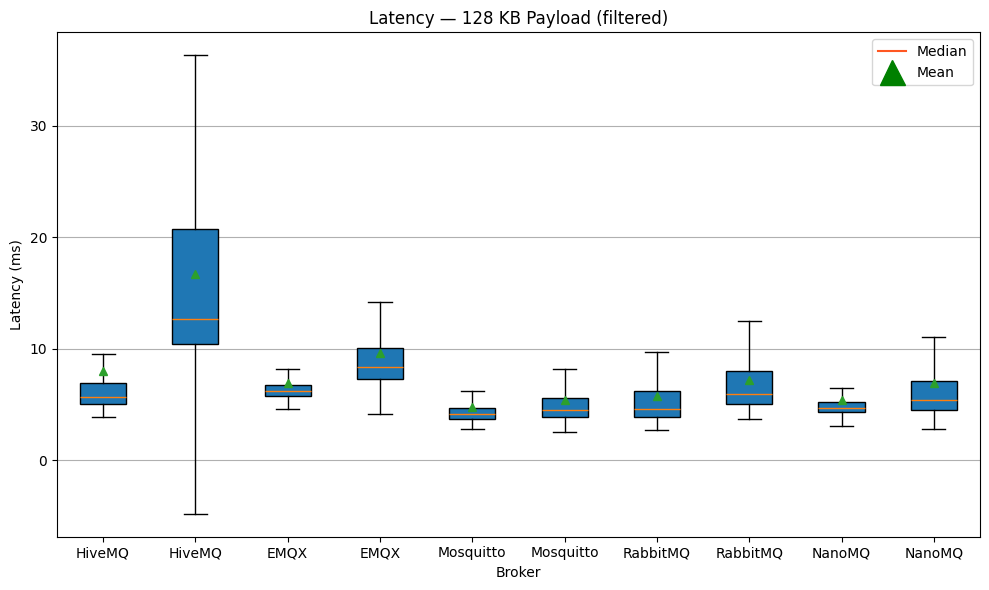

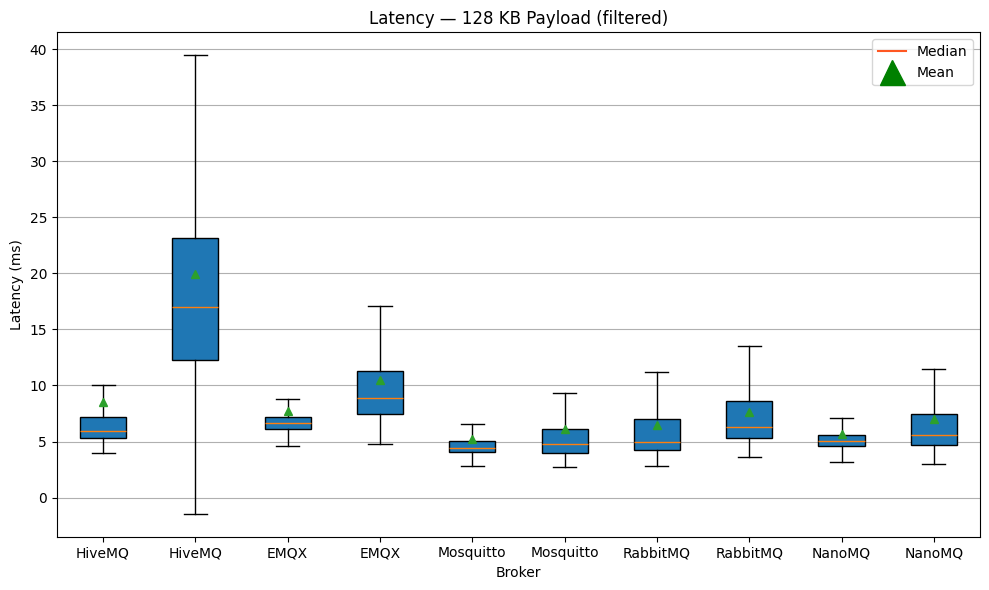

In [19]:
for i, subset in enumerate(gateways_sets):
    gateway = gateways[i]
    for ps in _ps_values:
        ps_subset = subset[subset['payload_size'] == ps]
        latency_data = []
        labels = []
        for aut in auts:
            data = ps_subset[ps_subset['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        if gateway.startswith('provider1.gateway') and len(latency_data) > 3:
            latency_data = latency_data[3:]
            labels = labels[3:]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showfliers=False, showmeans=True)
        ax.yaxis.grid(True)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ps_str = gateways_payloads[i] if i < len(gateways_payloads) else _ps_label(ps)
        ax.set_title(f'Latency — {ps_str.upper()} Payload (filtered)')
        lmedian = Line2D([], [], color="#FF5722", label="Median", markersize=18)
        green_triangle = Line2D([], [], color='green', marker='^', linestyle='None', markersize=18, label='Mean')
        ax.legend(handles=[lmedian, green_triangle], loc="upper right", ncol=1, fontsize=10)
        plt.show()


## Results for Gateway 1 - Provider 1 (Large Payload Size)

In [20]:
# gateway 1 (index 0)
_gw_idx = 0
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 0 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    for aut in auts:
        for qos in qoss:
            # Extract data for the current 'qos'
            data_for_qos = np_array[np_array['qos'] == qos]
            
            # Extract latency data for each 'aut' within the current 'qos'
            latency_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['latency']
        
            if len(latency_data_by_aut) == 0:
                continue
            
            delay = logs_parser.get_np_stats(latency_data_by_aut)
        
            rcv_msgs=len(latency_data_by_aut)
            avg_rcv_msgs = rcv_msgs/ logs_parser.NUM_RUNS
            
            # Extract uuid data for each 'aut' within the current 'qos'
            uuid_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['uuid']
            
            uniques = np.sum(np.unique_counts(uuid_data_by_aut).counts)
            duplicates_count = rcv_msgs - uniques
            avg_duplicates   = duplicates_count / logs_parser.NUM_RUNS
            
            lost_msgs=expected_msgs - rcv_msgs
            avg_lost_msg = (lost_msgs - duplicates_count)/ logs_parser.NUM_RUNS 
            
            # Extract uuid data for each 'topic_size' within the current 'qos'
            topic_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['topic_size']
            
            # Global topic sizes
            topic_size = logs_parser.get_np_stats(topic_size_data_by_aut)
            
            # Extract uuid data for each 'topic_size' within the current 'qos'
            payload_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['payload_size']
                
            
            # Global Payload sizes
            payload=logs_parser.get_np_stats(payload_size_data_by_aut)
            
            
            print(f'\n{aut.upper()}/{qos.upper()}\t\n')
            print(f'Total received msgs:{rcv_msgs}')
            print(f'Delay\tReceived Msg\tLost Msg\tDuplicated\tTopic')
            print(f'{format(delay["avg"], ".5f")}\t{avg_rcv_msgs}\t\t{avg_lost_msg}\t\t{avg_duplicates}\t\t{topic_size["avg"]}')
            
            print(f'stdev_delay: {delay["stdev"]}')
            print(f'max_delay {delay["max"]}')
            print(f'min_delay {delay["min"]}')
            print(f'max_topic_size: {topic_size["max"]}')
            print(f'min_topic_size {topic_size["max"]}')
            print(f'avg_payload: {payload["avg"]}')
            print(f'p_stdev_payload: {payload["stdev"]}')
            print(f'p_max: {payload["max"]}')
            print(f'p_min: {payload["min"]}')



AUT0_HIVEMQ_125KB/QOS0	

Total received msgs:2273
Delay	Received Msg	Lost Msg	Duplicated	Topic
8.02395	206.63636363636363		1611.5454545454545		0.0		19.0
stdev_delay: 26.124073884467638
max_delay 870.76220703125
min_delay 3.8671875
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_HIVEMQ_125KB_FIXED/QOS0	

Total received msgs:20000
Delay	Received Msg	Lost Msg	Duplicated	Topic
16.71463	1818.1818181818182		0.0		0.0		19.0
stdev_delay: 10.196833828260681
max_delay 266.349853515625
min_delay -42.608154296875
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_EMQX_125KB/QOS0	

Total received msgs:19435
Delay	Received Msg	Lost Msg	Duplicated	Topic
6.92929	1766.8181818181818		51.36363636363637		0.0		19.0
stdev_delay: 18.260026823166864
max_delay 1040.08056640625
min_delay 3.99755859375
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_ma

### Box Plot for Gateway 1 - Provider 1 Results

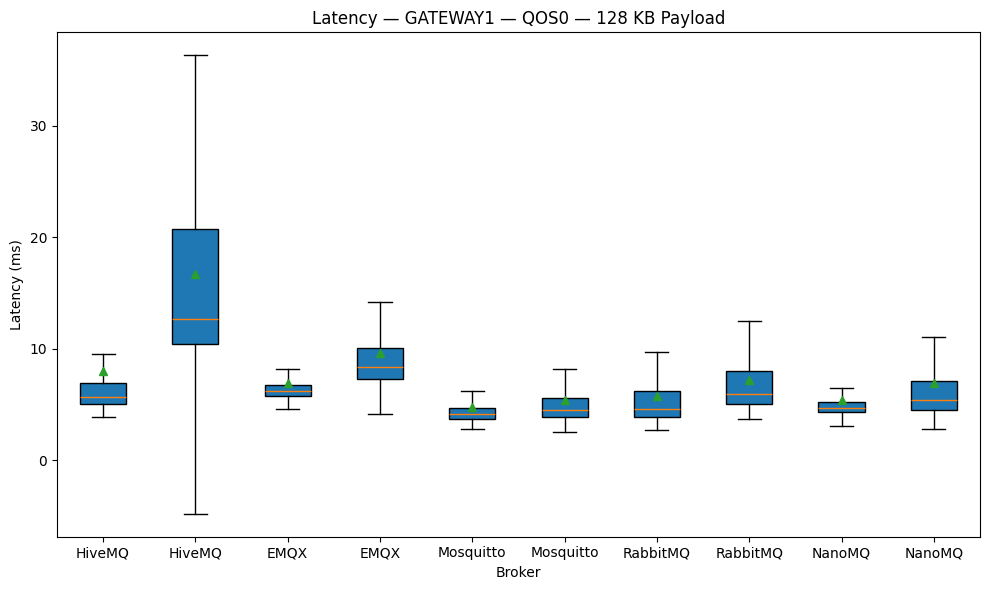

In [21]:
if np_array is None or len(np_array) == 0:
    print('[skip] No gateway data from previous cell')
else:
    for qos in qoss:
        for ps in _ps_values:
            data_ps = np_array[(np_array['qos'] == qos) & (np_array['payload_size'] == ps)]
            latency_data = []
            labels = []
            for aut in auts:
                data = data_ps[data_ps['aut'] == aut]['latency']
                if len(data) == 0:
                    continue
                latency_data.append(data)
                labels.append(_broker_label(aut))

            if not latency_data:
                continue

            fig, ax = plt.subplots(figsize=(10, 6))
            ax.boxplot(latency_data, patch_artist=True, showmeans=True, showfliers=False)
            ax.set_xticklabels(labels, rotation=0, ha='center')
            ax.set_xlabel('Broker')
            ax.set_ylabel('Latency (ms)')
            ax.set_title(f'Latency — {gateway.upper()} — {qos.upper()} — {_ps_label(ps)} Payload')
            plt.savefig(f"{gateway}_{_ps_label(ps).replace(' ','_')}-delay.pdf")
            plt.show()


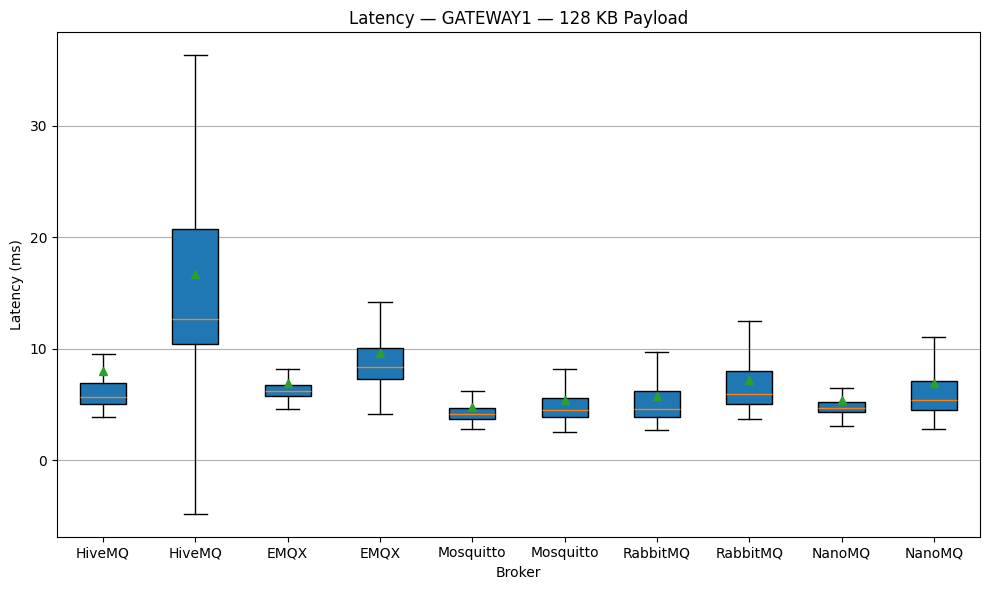

In [22]:
if np_array is None or len(np_array) == 0:
    print('[skip] No gateway data from previous cell')
else:
    for ps in _ps_values:
        ps_subset = np_array[np_array['payload_size'] == ps]
        latency_data = []
        labels = []
        for aut in auts:
            data = ps_subset[ps_subset['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showfliers=False, showmeans=True)
        ax.yaxis.grid(True)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency — {gateway.upper()} — {_ps_label(ps)} Payload')
        plt.show()


### Latency and Reliability for Gateway 1 - Provider 1 Load

/tmp/ipykernel_2830/2287565807.py:47: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(x[0:3], means[0:3], yerr=errors[0:3], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency', color='#1f77b4')
/tmp/ipykernel_2830/2287565807.py:49: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(x[3:6], means[3:6], yerr=errors[3:6], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')
/tmp/ipykernel_2830/2287565807.py:51: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(x[6:], means[6:], yerr=errors[6:], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle=

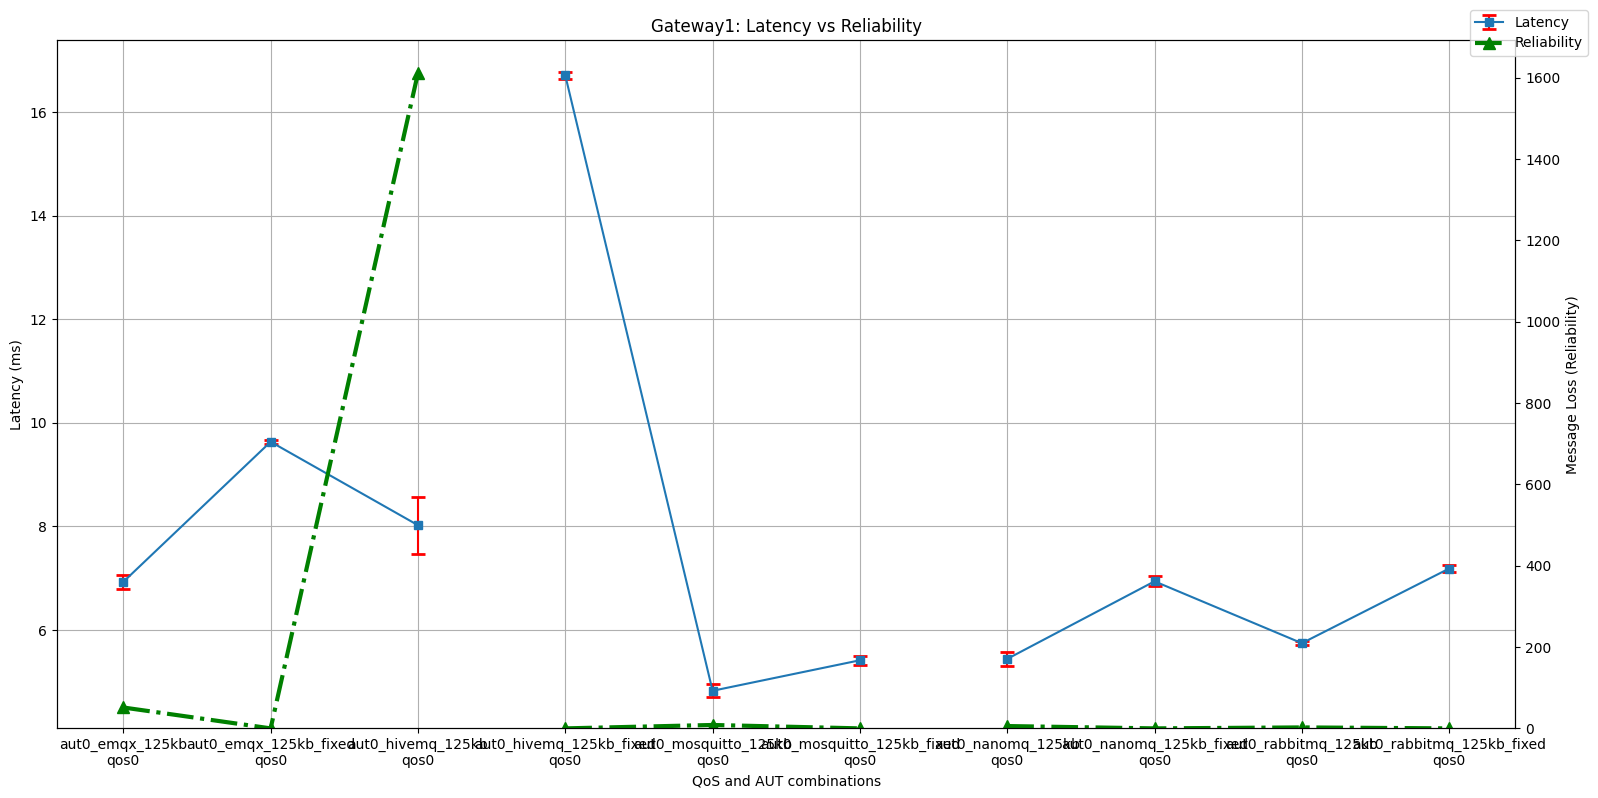

In [23]:
# gateway 1 (index 0)
_gw_idx = 0
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 0 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    # Extract latency data for each combination of 'qos' and 'aut'
    latency_data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
        for qos, aut in unique_combinations
    ]

    # Calculate mean and standard error for each combination
    means = [np.mean(sublist) for sublist in latency_data_by_combination]
    errors = [np.std(sublist) / np.sqrt(len(sublist)) for sublist in latency_data_by_combination]

    # Define x-coordinates (e.g., combination indices)
    x = np.arange(len(latency_data_by_combination))

    data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['uuid']
        for qos, aut in unique_combinations
    ]

    # Create the error bar plot
    #plt.figure(figsize=(16, 8))
    #plt.errorbar(x, means, yerr=errors, fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s')

    # Generate labels
    labels = [f'{aut}\n{qos}' for qos, aut in unique_combinations]

    # Create the main plot
    fig, ax1 = plt.subplots(figsize=(16, 8))


    # Subplots per QoS
    ax1.errorbar(x[0:3], means[0:3], yerr=errors[0:3], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency', color='#1f77b4')

    ax1.errorbar(x[3:6], means[3:6], yerr=errors[3:6], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')

    ax1.errorbar(x[6:], means[6:], yerr=errors[6:], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')

    # No line version
    # ax1.errorbar(x, means, yerr=errors, fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='', marker='s', label='Latency', color='#1f77b4')

    # Set labels and title
    ax1.set_xticklabels(labels)
    ax1.set_xlabel('QoS and AUT combinations')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_xticks(x)
    ax1.grid(True)

    # Set secondary y-axis to start at zero
    # ax1.set_ylim(bottom=0)


    # Calculate message loss for each combination
    loss=[((expected_msgs - len(sublist)) - (len(sublist) - (np.sum(np.unique_counts(sublist).counts))))
          / logs_parser.NUM_RUNS 
          for sublist in data_by_combination]

    # Create a secondary y-axis
    ax2 = ax1.twinx()

    # Plot data_by_combination_2 per QoS

    ax2.errorbar(x[0:3], loss[0:3], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3, label='Reliability')

    ax2.errorbar(x[3:6], loss[3:6], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3) 

    ax2.errorbar(x[6:], loss[6:], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3)

    # No line version
    # ax2.errorbar(x, loss, color='green', linestyle='', marker='^',markersize=8,linewidth=3, label='Reliability')

    ax2.set_ylabel('Message Loss (Reliability)')

    # Set secondary y-axis to start at zero
    ax2.set_ylim(bottom=0)

    # Other types of plots
    #ax2.bar(labels, loss, label='Reliability')
    #ax2.plot(x, loss, label='Reliability')




    fig.legend(loc='upper right', bbox_to_anchor=(1, 1))
    ax1.set_title(f'{gateway.replace("."," ").title()}: Latency vs Reliability')
    #plt.xticks(x, labels)
    #plt.grid(True)

    # Save the figure to a PDF file
    plt.savefig(f"{gateway}.pdf")

    # Display the plot
    plt.show()


### Message Loss Results for Gateway 1 - Provider 1 (Figure 7)

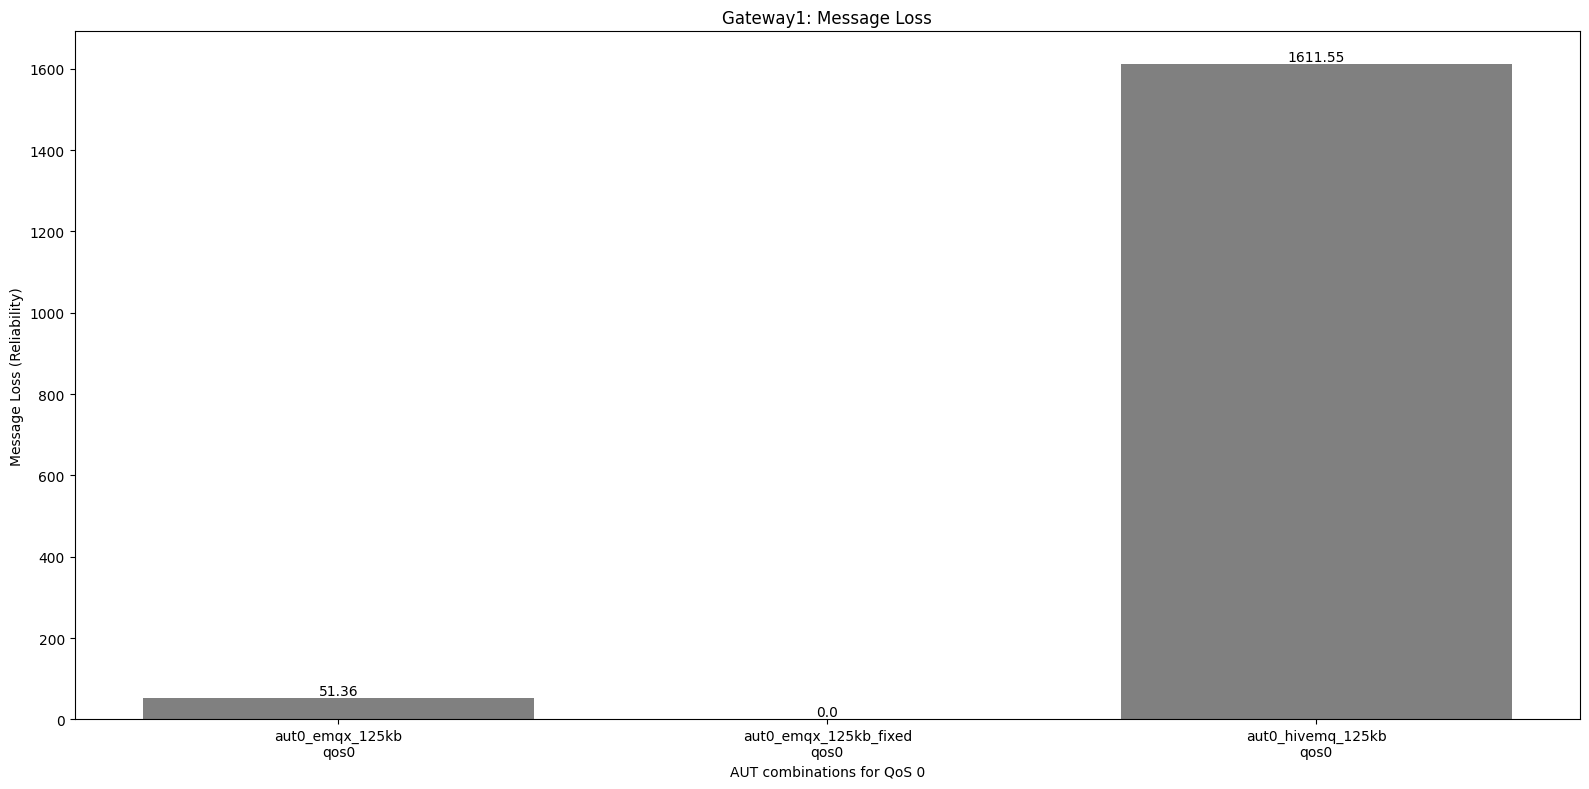

In [24]:
# gateway 1 (index 0)
_gw_idx = 0
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 0 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['uuid']
        for qos, aut in unique_combinations
    ]

    # Generate labels
    labels = [f'{aut}\n{qos}' for qos, aut in unique_combinations]

    # Calculate message loss for each combination
    loss=[((expected_msgs - len(sublist)) - (len(sublist) - (np.sum(np.unique_counts(sublist).counts))))
          / logs_parser.NUM_RUNS 
          for sublist in data_by_combination]

    # Create a figure and an axis for the plot
    fig, ax = plt.subplots()

    # Create the boxplot
    bars = ax.bar(labels[0:3], loss[0:3], label='Reliability',color="grey")

    # Annotate the bars with the mean values
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom', color='black')


    # Set labels and title
    ax.set_xlabel('AUT combinations for QoS 0')
    ax.set_ylabel('Message Loss (Reliability)')
    ax.set_title(f'{gateway.replace("."," ").title()}: Message Loss')


    # Save the figure to a PDF file
    plt.savefig(f"{gateway}-loss.pdf")

    # Display the plot
    plt.show()


## Results for Gateway 2 - Provider 1 (Medium Payload Size)

In [25]:
# gateway 2 (index 1)
_gw_idx = 1
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 1 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    for aut in auts:
        for qos in qoss:
            # Extract data for the current 'qos'
            data_for_qos = np_array[np_array['qos'] == qos]
            
            # Extract latency data for each 'aut' within the current 'qos'
            latency_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['latency']
        
            if len(latency_data_by_aut) == 0:
                continue
            
            delay = logs_parser.get_np_stats(latency_data_by_aut)
        
            rcv_msgs=len(latency_data_by_aut)
            avg_rcv_msgs = rcv_msgs/ logs_parser.NUM_RUNS
            
            # Extract uuid data for each 'aut' within the current 'qos'
            uuid_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['uuid']
            
            uniques = np.sum(np.unique_counts(uuid_data_by_aut).counts)
            duplicates_count = rcv_msgs - uniques
            avg_duplicates   = duplicates_count / logs_parser.NUM_RUNS
            
            lost_msgs=expected_msgs - rcv_msgs
            avg_lost_msg = (lost_msgs - duplicates_count)/ logs_parser.NUM_RUNS 
            
            # Extract uuid data for each 'topic_size' within the current 'qos'
            topic_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['topic_size']
            
            # Global topic sizes
            topic_size = logs_parser.get_np_stats(topic_size_data_by_aut)
            
            # Extract uuid data for each 'topic_size' within the current 'qos'
            payload_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['payload_size']
                
            
            # Global Payload sizes
            payload=logs_parser.get_np_stats(payload_size_data_by_aut)
            
            
            print(f'\n{aut.upper()}/{qos.upper()}\t\n')
            print(f'Total received msgs:{rcv_msgs}')
            print(f'Delay\tReceived Msg\tLost Msg\tDuplicated\tTopic')
            print(f'{delay["avg"]}\t{avg_rcv_msgs}\t{avg_lost_msg}\t{avg_duplicates}\t{topic_size["avg"]}')
            
            print(f'stdev_delay: {delay["stdev"]}')
            print(f'max_delay {delay["max"]}')
            print(f'min_delay {delay["min"]}')
            print(f'max_topic_size: {topic_size["max"]}')
            print(f'min_topic_size {topic_size["max"]}')
            print(f'avg_payload: {payload["avg"]}')
            print(f'p_stdev_payload: {payload["stdev"]}')
            print(f'p_max: {payload["max"]}')
            print(f'p_min: {payload["min"]}')



AUT0_HIVEMQ_125KB/QOS0	

Total received msgs:2974
Delay	Received Msg	Lost Msg	Duplicated	Topic
8.525333899656397	270.3636363636364	1547.8181818181818	0.0	19.0
stdev_delay: 31.4018921279623
max_delay 874.3193359375
min_delay 3.943603515625
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_HIVEMQ_125KB_FIXED/QOS0	

Total received msgs:20000
Delay	Received Msg	Lost Msg	Duplicated	Topic
19.948187658691406	1818.1818181818182	0.0	0.0	19.0
stdev_delay: 13.015746295207755
max_delay 619.372314453125
min_delay -33.994873046875
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_EMQX_125KB/QOS0	

Total received msgs:19650
Delay	Received Msg	Lost Msg	Duplicated	Topic
7.688040364583333	1786.3636363636363	31.818181818181817	0.0	19.0
stdev_delay: 26.553250934230928
max_delay 1085.981689453125
min_delay 4.050048828125
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0


### Box Plot for Gateway 2 - Provider 1 results

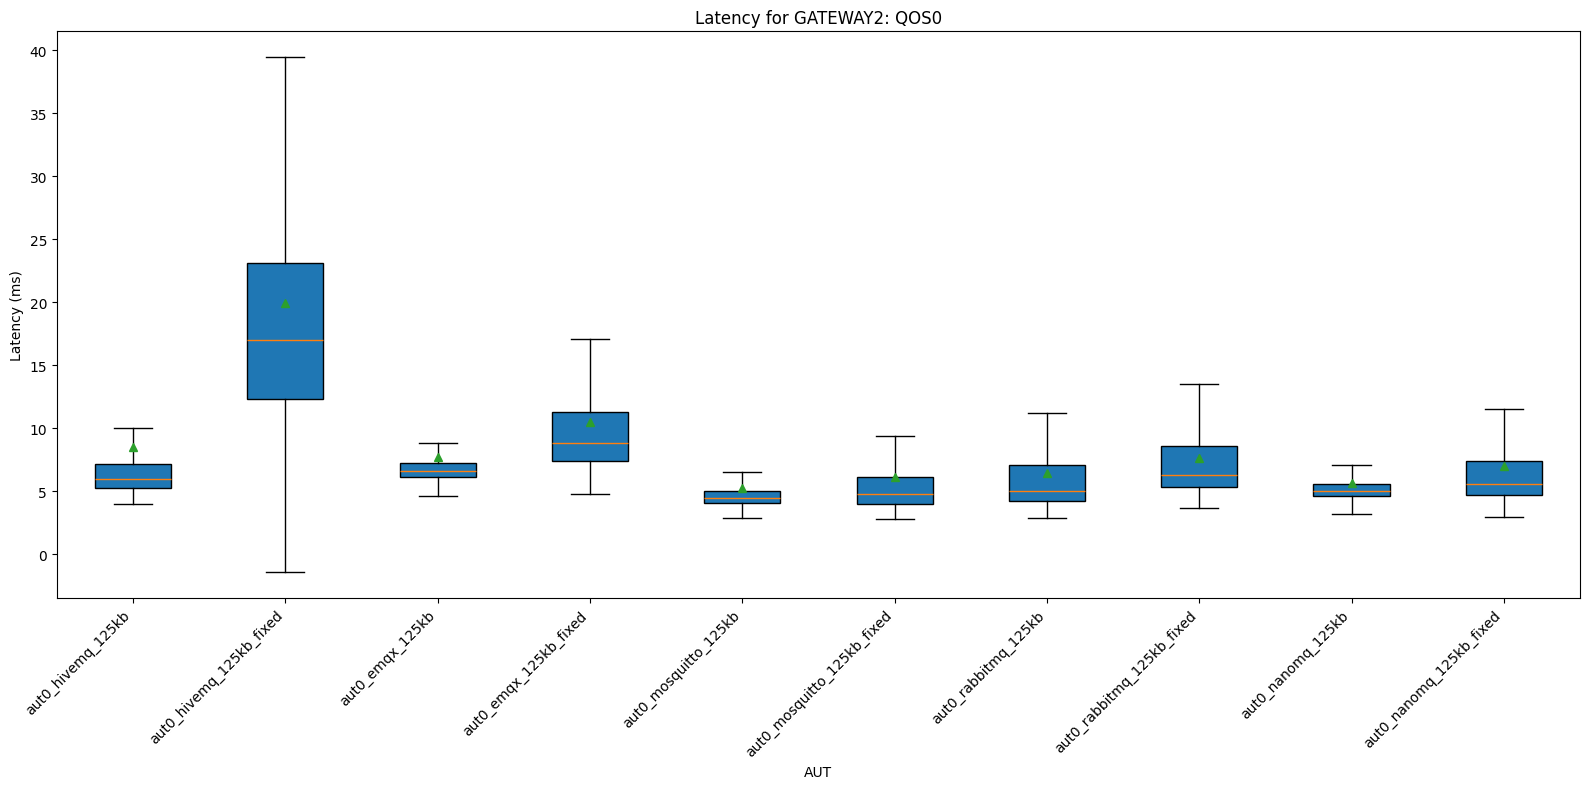

In [26]:
if np_array is None or len(np_array) == 0:
    print('[skip] No gateway data from previous cell')
else:
    # Creating a plot for each unique 'qos' value
    for qos in qoss:
        # Extract data for the current 'qos'
        data_for_qos = np_array[np_array['qos'] == qos]
        
        # Extract latency data for each 'aut' within the current 'qos'
        latency_data_by_aut = [
            data_for_qos[data_for_qos['aut'] == aut]['latency']
            for aut in auts
        ]
        
        # Generate labels for the x-axis based on 'aut'
        labels = [f'{aut}' for aut in auts]
        
        # Create a figure and an axis for the current 'qos'
        fig, ax = plt.subplots()
        
        # Create the boxplot
        ax.boxplot(latency_data_by_aut, patch_artist=True,showmeans=True,showfliers=False)
        
        # Set labels and title
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_xlabel('AUT')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency for {gateway.upper()}: {qos.upper()}')

        # Save the figure to a PDF file
        plt.savefig(f"{gateway}-delay.pdf")

        # Display the plot
        plt.show()


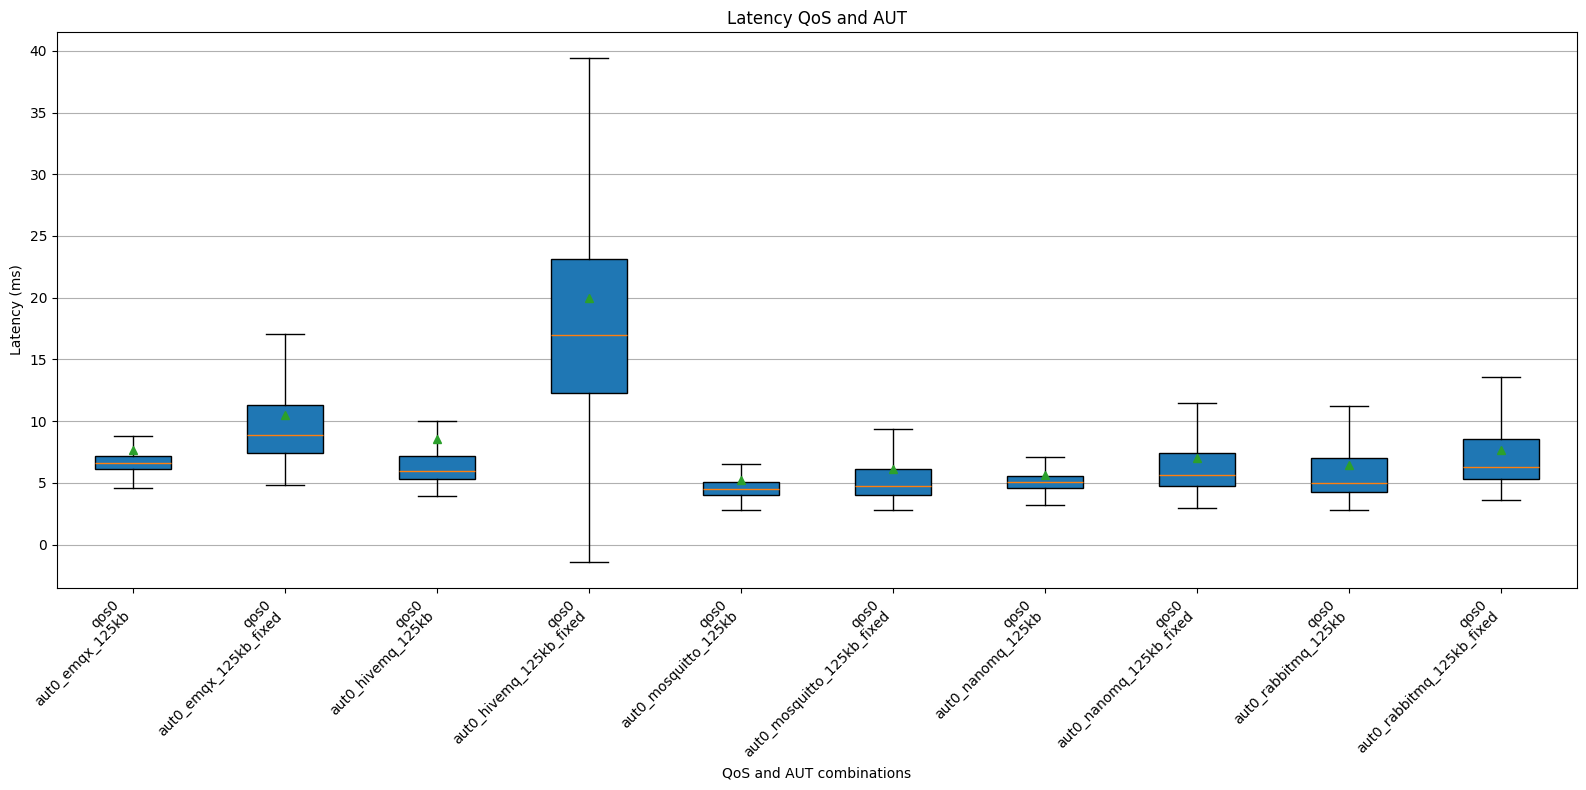

In [27]:
if np_array is None or len(np_array) == 0:
    print('[skip] No gateway data from previous cell')
else:
    # Extract latency data for each 'qos' group
    latency_data_by_qos = [np_array[np_array['qos'] == qos]['latency'] for qos in qoss]

    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    # Extract latency data for each combination of 'qos' and 'aut'
    latency_data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
        for qos, aut in unique_combinations
    ]

    #loss_data_by_combination = = [
    #    np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
    #    for qos, aut in unique_combinations
    # ]

    # Generate labels
    labels = [f'{qos}\n{aut}' for qos, aut in unique_combinations]

    # Create a figure and an axis for the plot
    fig, ax = plt.subplots()

    # Create the boxplot
    ax.boxplot(latency_data_by_combination, patch_artist=True, showfliers=False,showmeans=True)

    # Add grid lines
    ax.yaxis.grid(True)

    # Set labels and title
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel('QoS and AUT combinations')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency QoS and AUT')

    # Display the plot
    plt.show()


### Latency and Reliability for Gateway 2 - Provider 1 Load

/tmp/ipykernel_2830/3036688011.py:42: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(x[0:3], means[0:3], yerr=errors[0:3], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency', color='#1f77b4')
/tmp/ipykernel_2830/3036688011.py:44: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(x[3:6], means[3:6], yerr=errors[3:6], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')
/tmp/ipykernel_2830/3036688011.py:46: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(x[6:], means[6:], yerr=errors[6:], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle=

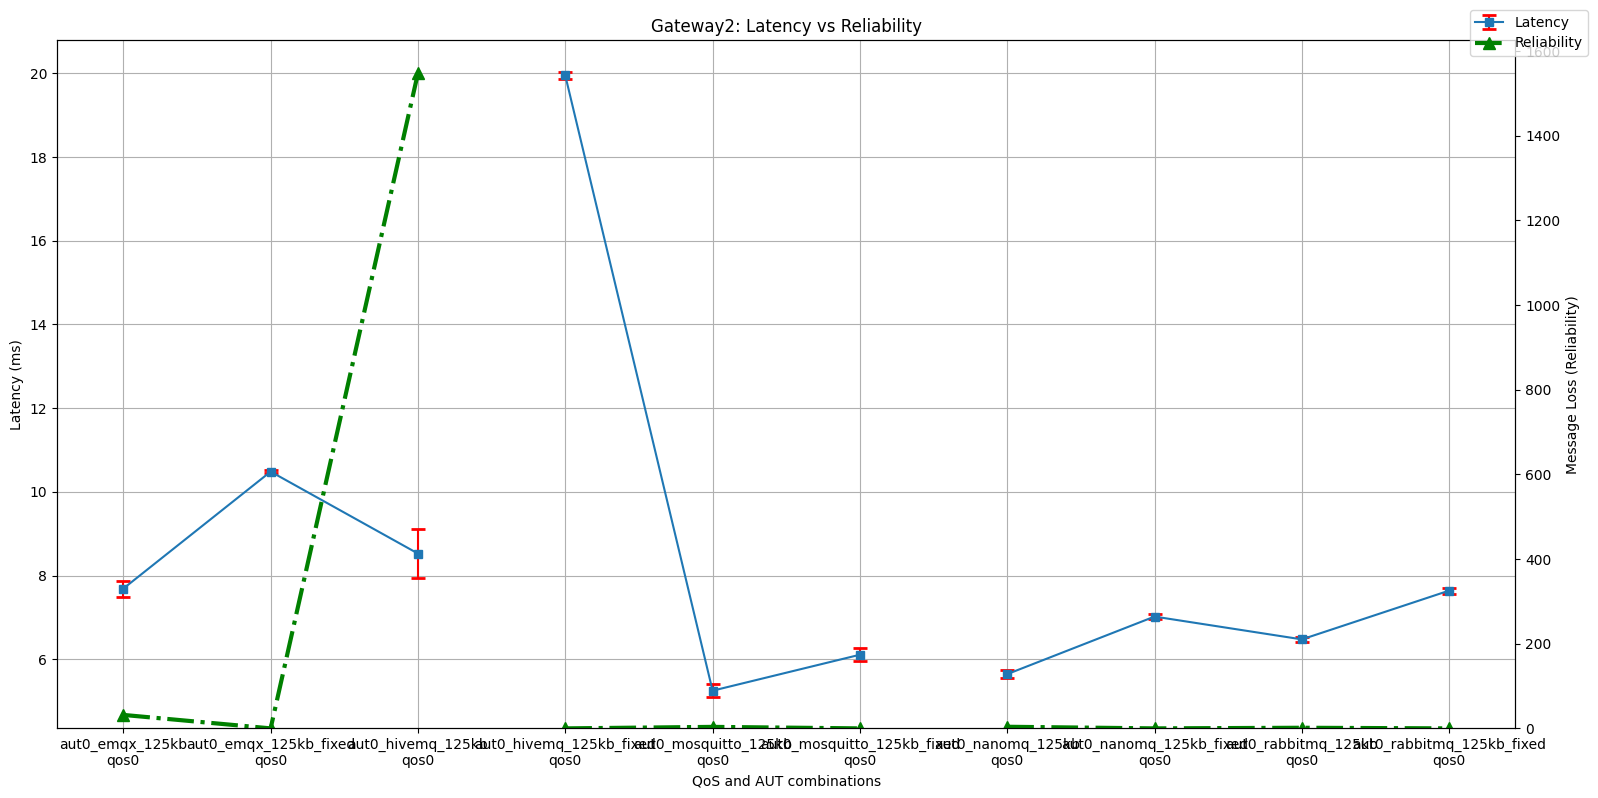

In [28]:
# gateway 2 (index 1)
_gw_idx = 1
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 1 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 2



    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    # Extract latency data for each combination of 'qos' and 'aut'
    latency_data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
        for qos, aut in unique_combinations
    ]

    # Calculate mean and standard error for each combination
    means = [np.mean(sublist) for sublist in latency_data_by_combination]
    errors = [np.std(sublist) / np.sqrt(len(sublist)) for sublist in latency_data_by_combination]

    # Define x-coordinates (e.g., combination indices)
    x = np.arange(len(latency_data_by_combination))

    data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['uuid']
        for qos, aut in unique_combinations
    ]

    # Generate labels
    labels = [f'{aut}\n{qos}' for qos, aut in unique_combinations]

    # Create the main plot
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Subplots per QoS
    ax1.errorbar(x[0:3], means[0:3], yerr=errors[0:3], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency', color='#1f77b4')

    ax1.errorbar(x[3:6], means[3:6], yerr=errors[3:6], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')

    ax1.errorbar(x[6:], means[6:], yerr=errors[6:], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')

    # No line version
    # ax1.errorbar(x, means, yerr=errors, fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency')

    # Set secondary y-axis to start at zero
    # ax1.set_ylim(bottom=0)


    # Set labels and title
    ax1.set_xticklabels(labels)
    ax1.set_xlabel('QoS and AUT combinations')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_xticks(x)
    ax1.grid(True)
    #plt.ylabel('Latency (ms)')

    # Calculate message loss for each combination
    loss=[((expected_msgs - len(sublist)) - (len(sublist) - (np.sum(np.unique_counts(sublist).counts))))
          / logs_parser.NUM_RUNS 
          for sublist in data_by_combination]

    # Create a secondary y-axis
    ax2 = ax1.twinx()

    # Plot data_by_combination_2 per QoS

    ax2.errorbar(x[0:3], loss[0:3], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3, label='Reliability')

    ax2.errorbar(x[3:6], loss[3:6], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3) 

    ax2.errorbar(x[6:], loss[6:], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3)

    ax2.set_ylabel('Message Loss (Reliability)')

    # Set secondary y-axis to start at zero
    ax2.set_ylim(bottom=0)


    # No line version
    # ax2.errorbar(x, loss, color='green', linestyle='-.', marker='^',markersize=8,linewidth=3, label='Reliability')

    # Other types of plots
    #ax2.bar(labels, loss, label='Reliability')
    #ax2.plot(x, loss, label='Reliability')


    fig.legend(loc='upper right', bbox_to_anchor=(1, 1))
    ax1.set_title(f'{gateway.replace("."," ").title()}: Latency vs Reliability')
    #plt.xticks(x, labels)
    #plt.grid(True)

    # Save the figure to a PDF file
    plt.savefig(f"{gateway}.pdf")

    # Display the plot
    plt.show()


### Message Loss Results for Gateway 2 - Provider 1 (Figure 8)

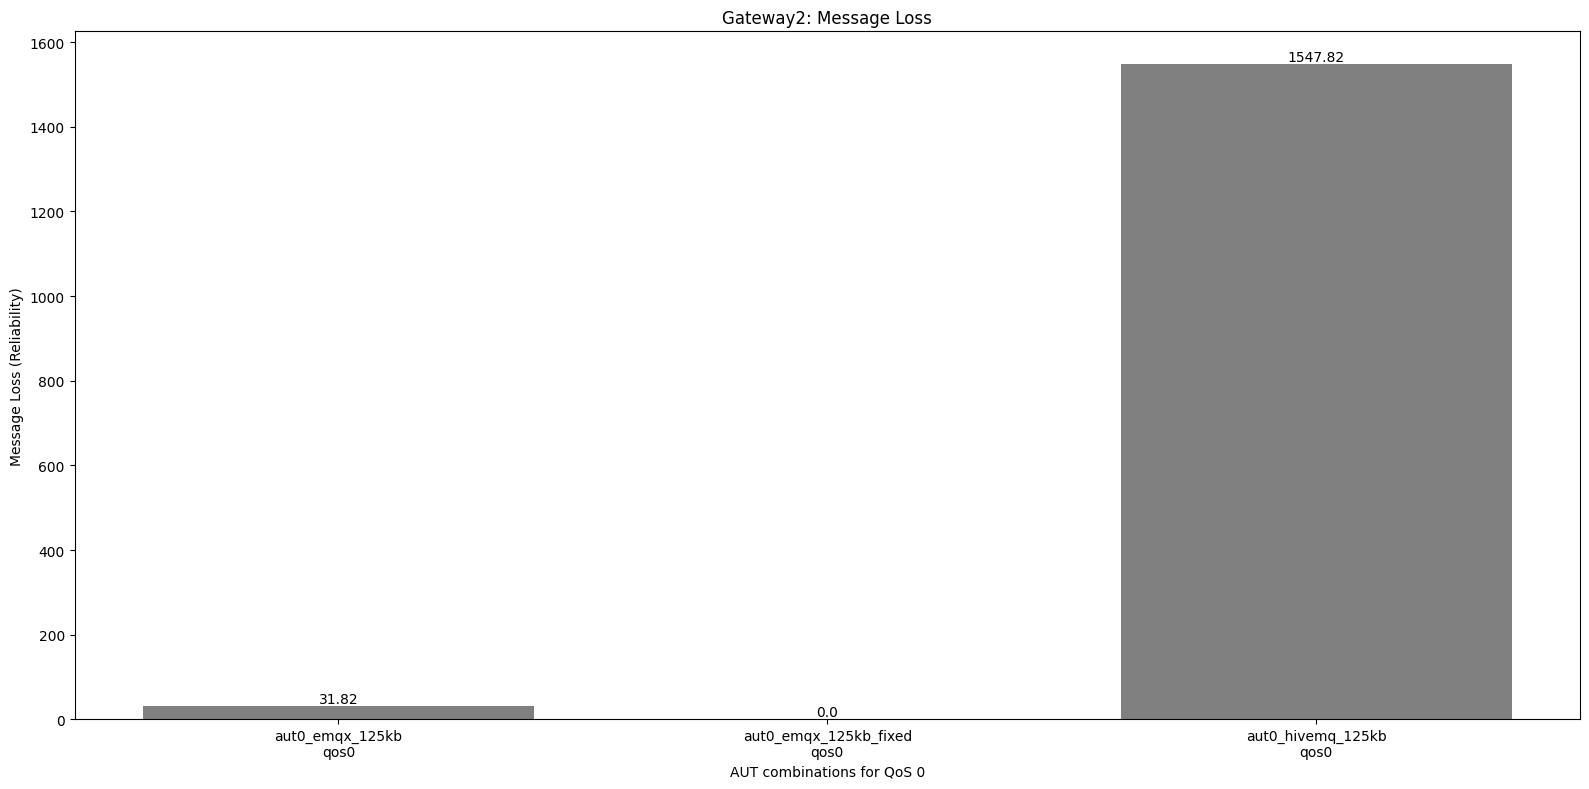

In [29]:
# gateway 2 (index 1)
_gw_idx = 1
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 1 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['uuid']
        for qos, aut in unique_combinations
    ]

    # Generate labels
    labels = [f'{aut}\n{qos}' for qos, aut in unique_combinations]

    # Calculate message loss for each combination
    loss=[((expected_msgs - len(sublist)) - (len(sublist) - (np.sum(np.unique_counts(sublist).counts))))
          / logs_parser.NUM_RUNS 
          for sublist in data_by_combination]

    # Create a figure and an axis for the plot
    fig, ax = plt.subplots()

    # Create the boxplot
    bars = ax.bar(labels[0:3], loss[0:3], label='Reliability',color="grey")

    # Annotate the bars with the mean values
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom', color='black')


    # Set labels and title
    ax.set_xlabel('AUT combinations for QoS 0')
    ax.set_ylabel('Message Loss (Reliability)')
    ax.set_title(f'{gateway.replace("."," ").title()}: Message Loss')


    # Save the figure to a PDF file
    plt.savefig(f"{gateway}-loss.pdf")

    # Display the plot
    plt.show()


## Results for Gateway 1 - Provider 2 (Small Payload Size)

In [30]:
# gateway 3 (index 2)
_gw_idx = 2
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 2 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    for aut in auts:
        for qos in qoss:
            # Extract data for the current 'qos'
            data_for_qos = np_array[np_array['qos'] == qos]
            
            # Extract latency data for each 'aut' within the current 'qos'
            latency_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['latency']
        
            if len(latency_data_by_aut) == 0:
                continue
            
            delay = logs_parser.get_np_stats(latency_data_by_aut)
        
            rcv_msgs=len(latency_data_by_aut)
            avg_rcv_msgs = rcv_msgs/ logs_parser.NUM_RUNS
            
            # Extract uuid data for each 'aut' within the current 'qos'
            uuid_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['uuid']
            
            uniques = np.sum(np.unique_counts(uuid_data_by_aut).counts)
            duplicates_count = rcv_msgs - uniques
            avg_duplicates   = duplicates_count / logs_parser.NUM_RUNS
            
            lost_msgs=expected_msgs - rcv_msgs
            avg_lost_msg = (lost_msgs - duplicates_count)/ logs_parser.NUM_RUNS 
            
            # Extract uuid data for each 'topic_size' within the current 'qos'
            topic_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['topic_size']
            
            # Global topic sizes
            topic_size = logs_parser.get_np_stats(topic_size_data_by_aut)
            
            # Extract uuid data for each 'topic_size' within the current 'qos'
            payload_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['payload_size']
                
            
            # Global Payload sizes
            payload=logs_parser.get_np_stats(payload_size_data_by_aut)
            
            
            print(f'\n{aut.upper()}/{qos.upper()}\t\n')
            print(f'Delay\tReceived Msg\tLost Msg\tDuplicated\tTopic')
            print(f'{delay["avg"]}\t{avg_rcv_msgs}\t{avg_lost_msg}\t{avg_duplicates}\t{topic_size["avg"]}')
            
            print(f'stdev_delay: {delay["stdev"]}')
            print(f'max_delay {delay["max"]}')
            print(f'min_delay {delay["min"]}')
            print(f'max_topic_size: {topic_size["max"]}')
            print(f'min_topic_size {topic_size["max"]}')
            print(f'avg_payload: {payload["avg"]}')
            print(f'p_stdev_payload: {payload["stdev"]}')
            print(f'p_max: {payload["max"]}')
            print(f'p_min: {payload["min"]}')


[skip] Only 2 gateway(s) available, index 2 not present


### Box Plot for Gateway 1 - Provider 2 Results

In [31]:
if np_array is None or len(np_array) == 0:
    print('[skip] No gateway data from previous cell')
else:
    # Creating a plot for each unique 'qos' value
    for qos in qoss:
        # Extract data for the current 'qos'
        data_for_qos = np_array[np_array['qos'] == qos]
        
        # Extract latency data for each 'aut' within the current 'qos'
        latency_data_by_aut = [
            data_for_qos[data_for_qos['aut'] == aut]['latency']
            for aut in auts
        ]
        
        # Generate labels for the x-axis based on 'aut'
        labels = [f'{aut}' for aut in auts]
        
        # Create a figure and an axis for the current 'qos'
        fig, ax = plt.subplots()
        
        # Create the boxplot
        ax.boxplot(latency_data_by_aut, patch_artist=True,showmeans=True,showfliers=False)
        
        # Set labels and title
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_xlabel('AUT')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency for {gateway.upper()}: {qos.upper()}')

        # Save the figure to a PDF file
        plt.savefig(f"{gateway}-delay.pdf")

        # Display the plot
        plt.show()


[skip] No gateway data from previous cell


In [32]:
if np_array is None or len(np_array) == 0:
    print('[skip] No gateway data from previous cell')
else:
    # Extract latency data for each 'qos' group
    latency_data_by_qos = [np_array[np_array['qos'] == qos]['latency'] for qos in qoss]

    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    # Extract latency data for each combination of 'qos' and 'aut'
    latency_data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
        for qos, aut in unique_combinations
    ]

    #loss_data_by_combination = = [
    #    np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
    #    for qos, aut in unique_combinations
    # ]

    # Generate labels
    labels = [f'{qos}\n{aut}' for qos, aut in unique_combinations]

    # Create a figure and an axis for the plot
    fig, ax = plt.subplots()

    # Create the boxplot
    ax.boxplot(latency_data_by_combination, patch_artist=True, showfliers=False,showmeans=True)

    # Add grid lines
    ax.yaxis.grid(True)

    # Set labels and title
    ax.set_xticklabels(labels, rotation=90, ha='right')
    ax.set_xlabel('QoS and AUT combinations')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency QoS and AUT')

    # Display the plot
    plt.show()


[skip] No gateway data from previous cell


### Latency and Reliability for Gateway 1 - Provider 2 Load

In [33]:
# gateway 3 (index 2)
_gw_idx = 2
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 2 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 2, gateway 1



    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    # Extract latency data for each combination of 'qos' and 'aut'
    latency_data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['latency']
        for qos, aut in unique_combinations
    ]

    # Calculate mean and standard error for each combination
    means = [np.mean(sublist) for sublist in latency_data_by_combination]
    errors = [np.std(sublist) / np.sqrt(len(sublist)) for sublist in latency_data_by_combination]

    # Define x-coordinates (e.g., combination indices)
    x = np.arange(len(latency_data_by_combination))

    data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['uuid']
        for qos, aut in unique_combinations
    ]

    # Generate labels
    labels = [f'{aut}\n{qos}' for qos, aut in unique_combinations]

    # Create the main plot
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # Subplots per QoS
    ax1.errorbar(x[0:3], means[0:3], yerr=errors[0:3], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency', color='#1f77b4')

    ax1.errorbar(x[3:6], means[3:6], yerr=errors[3:6], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')

    ax1.errorbar(x[6:], means[6:], yerr=errors[6:], fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', color='#1f77b4')

    # No line version
    # ax1.errorbar(x, means, yerr=errors, fmt='o', capsize=5, capthick=2, ecolor='red', linestyle='-', marker='s', label='Latency')

    # Set labels and title
    ax1.set_xticklabels(labels)
    ax1.set_xlabel('QoS and AUT combinations')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_xticks(x)
    ax1.grid(True)

    # Calculate message loss for each combination
    loss=[((expected_msgs - len(sublist)) - (len(sublist) - (np.sum(np.unique_counts(sublist).counts))))
          / logs_parser.NUM_RUNS 
          for sublist in data_by_combination]

    # Create a secondary y-axis
    ax2 = ax1.twinx()

    # Plot data_by_combination_2 per QoS
    ax2.errorbar(x[0:3], loss[0:3], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3, label='Reliability')

    ax2.errorbar(x[3:6], loss[3:6], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3) 

    ax2.errorbar(x[6:], loss[6:], color='green', linestyle='-.', marker='^',markersize=8,linewidth=3)

    ax2.set_ylabel('Message Loss (Reliability)')

    # Set secondary y-axis to start at zero
    ax2.set_ylim(bottom=0)

    # No line version
    # ax2.errorbar(x, loss, color='green', linestyle='-.', marker='^',markersize=8,linewidth=3, label='Reliability')

    # Other types of plots
    #ax2.bar(labels, loss, label='Reliability')
    #ax2.plot(x, loss, label='Reliability')


    fig.legend(loc='upper right', bbox_to_anchor=(1, 1))
    ax1.set_title(f'{gateway.replace("."," ").title()}: Latency vs Reliability')
    #plt.xticks(x, labels)
    #plt.grid(True)

    # Save the figure to a PDF file
    plt.savefig(f"{gateway}.pdf")

    # Display the plot
    plt.show()


[skip] Only 2 gateway(s) available, index 2 not present


### Message Loss Results for Gateway 2 - Provider 1 (Figure 9)

In [34]:
# gateway 3 (index 2)
_gw_idx = 2
if _gw_idx >= len(gateways):
    print(f"[skip] Only {len(gateways)} gateway(s) available, index 2 not present")
    np_array = None
else:
    gateway = gateways[_gw_idx]
    expected_msgs = _expected_msgs_for_gateway(gateway)
    np_array = gateways_sets[_gw_idx]
    # Get data for all AUTs and QoS for provider 1, gateway 1



    # Extract unique combinations of 'qos' and 'aut'
    unique_combinations = np.unique(np_array[['qos', 'aut']])

    data_by_combination = [
        np_array[(np_array['qos'] == qos) & (np_array['aut'] == aut)]['uuid']
        for qos, aut in unique_combinations
    ]

    # Generate labels
    labels = [f'{aut}\n{qos}' for qos, aut in unique_combinations]

    # Calculate message loss for each combination
    loss=[((expected_msgs - len(sublist)) - (len(sublist) - (np.sum(np.unique_counts(sublist).counts))))
          / logs_parser.NUM_RUNS 
          for sublist in data_by_combination]

    # Create a figure and an axis for the plot
    fig, ax = plt.subplots()

    # Create the boxplot
    bars = ax.bar(labels[0:3], loss[0:3], label='Reliability',color="grey")

    # Annotate the bars with the mean values
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom', color='black')


    # Set labels and title
    ax.set_xlabel('AUT combinations for QoS 0')
    ax.set_ylabel('Message Loss (Reliability)')
    ax.set_title(f'{gateway.replace("."," ").title()}: Message Loss')


    # Save the figure to a PDF file
    plt.savefig(f"{gateway}-loss.pdf")

    # Display the plot
    plt.show()


[skip] Only 2 gateway(s) available, index 2 not present


# Topic Overhead

In [35]:
topic_overheads = [15.0, 29.0]
topics_overhead_sets = list()
for topic_overhead in topic_overheads:
    subset = np_array_global[np_array_global['topic_size'] == topic_overhead]
    topics_overhead_sets.append(subset)
    for ps in _ps_values:
        ps_subset = subset[subset['payload_size'] == ps]
        latency_data = []
        labels = []
        for aut in auts:
            data = ps_subset[ps_subset['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showmeans=True, showfliers=False)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency — Topic Overhead {topic_overhead} — {_ps_label(ps)} Payload')
        plt.show()


## Latency per Gateway

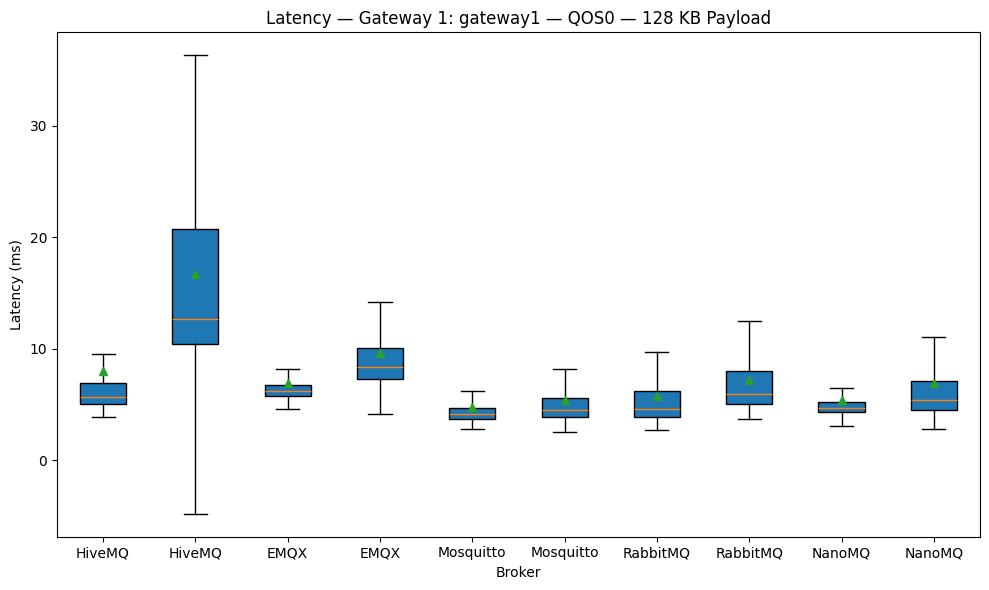

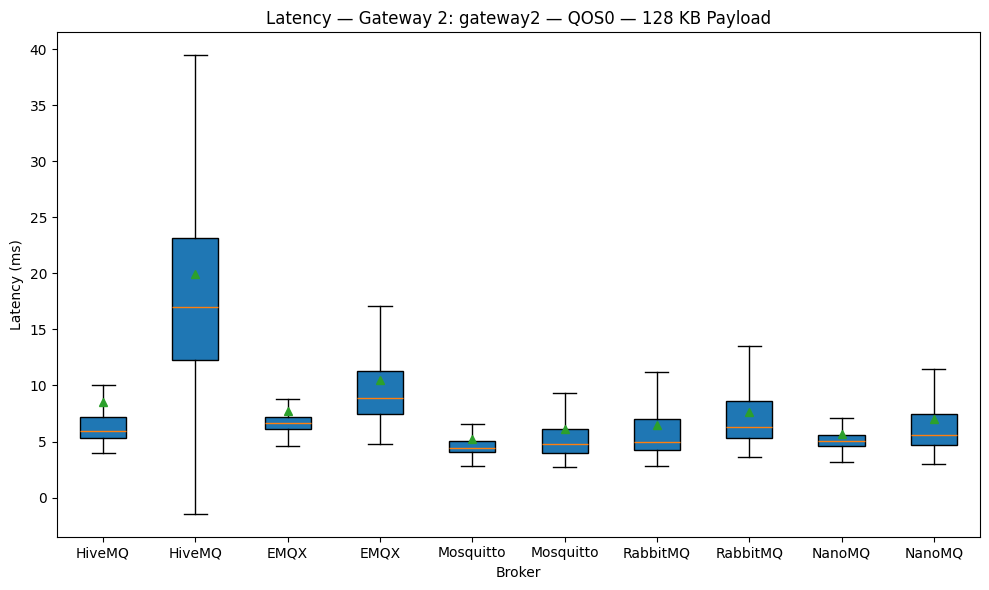

In [36]:
for i, gateway in enumerate(gateways):
    np_array = gateways_sets[i]
    for qos in qoss:
        for ps in _ps_values:
            data_ps = np_array[(np_array['qos'] == qos) & (np_array['payload_size'] == ps)]
            latency_data = []
            labels = []
            for aut in auts:
                data = data_ps[data_ps['aut'] == aut]['latency']
                if len(data) == 0:
                    continue
                latency_data.append(data)
                labels.append(_broker_label(aut))

            if not latency_data:
                continue

            fig, ax = plt.subplots(figsize=(10, 6))
            ax.boxplot(latency_data, patch_artist=True, showmeans=True, showfliers=False)
            ax.set_xticklabels(labels, rotation=0, ha='center')
            ax.set_xlabel('Broker')
            ax.set_ylabel('Latency (ms)')
            ax.set_title(f'Latency — Gateway {i+1}: {gateway} — {qos.upper()} — {_ps_label(ps)} Payload')
            plt.show()


# Results Plots

## Latency Plots for Provider 1

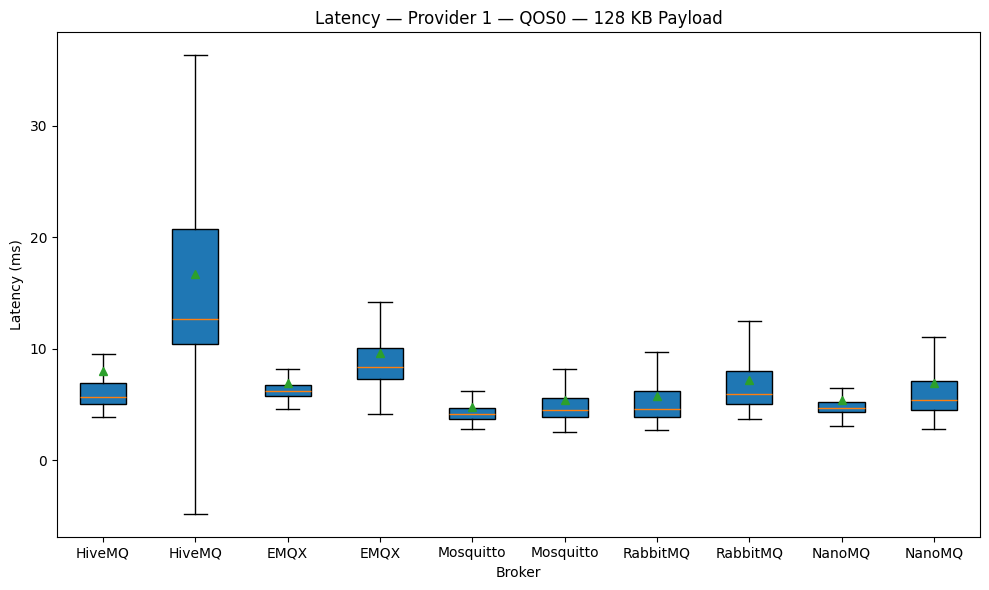

In [37]:
np_array = providers_sets[0]

for qos in qoss:
    for ps in _ps_values:
        data_ps = np_array[(np_array['qos'] == qos) & (np_array['payload_size'] == ps)]
        latency_data = []
        labels = []
        for aut in auts:
            data = data_ps[data_ps['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showmeans=True, showfliers=False)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency — Provider 1 — {qos.upper()} — {_ps_label(ps)} Payload')
        plt.show()


# Results Provider 1

In [38]:
# Stats

# Get data for all AUTs and QoS for provider 1
np_array= providers_sets[0]

for aut in auts:
    for qos in qoss:
        # Extract data for the current 'qos'
        data_for_qos = np_array[np_array['qos'] == qos]
        
        # Extract latency data for each 'aut' within the current 'qos'
        latency_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['latency']
    
        if len(latency_data_by_aut) == 0:
            continue
        
        delay = logs_parser.get_np_stats(latency_data_by_aut)
    
        rcv_msgs=len(latency_data_by_aut)
        avg_rcv_msgs = rcv_msgs/ logs_parser.NUM_RUNS
        
        # Extract uuid data for each 'aut' within the current 'qos'
        uuid_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['uuid']
        
        uniques = np.sum(np.unique_counts(uuid_data_by_aut).counts)
        duplicates_count = rcv_msgs - uniques
        avg_duplicates   = duplicates_count / logs_parser.NUM_RUNS
        
        expected_msgs = _expected_msgs_for_gateway(providers_tp[0].split("/")[-1])
        lost_msgs = expected_msgs - rcv_msgs
        avg_lost_msg = (lost_msgs - duplicates_count)/ logs_parser.NUM_RUNS 
        
        # Extract uuid data for each 'topic_size' within the current 'qos'
        topic_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['topic_size']
        
        # Global topic sizes
        topic_size = logs_parser.get_np_stats(topic_size_data_by_aut)
        
        # Extract uuid data for each 'topic_size' within the current 'qos'
        payload_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['payload_size']
            
        
        # Global Payload sizes
        payload=logs_parser.get_np_stats(payload_size_data_by_aut)
        
        
        print(f'\n{aut.upper()}/{qos.upper()}\t\n')
        print(f'Delay\tReceived Msg\tLost Msg\tDuplicated\tTopic')
        print(f'{delay["avg"]}\t{avg_rcv_msgs}\t{avg_lost_msg}\t{avg_duplicates}\t{topic_size["avg"]}')
        
        print(f'stdev_delay: {delay["stdev"]}')
        print(f'max_delay {delay["max"]}')
        print(f'min_delay {delay["min"]}')
        print(f'max_topic_size: {topic_size["max"]}')
        print(f'min_topic_size {topic_size["max"]}')
        print(f'avg_payload: {payload["avg"]}')
        print(f'p_stdev_payload: {payload["stdev"]}')
        print(f'p_max: {payload["max"]}')
        print(f'p_min: {payload["min"]}')
        


AUT0_HIVEMQ_125KB/QOS0	

Delay	Received Msg	Lost Msg	Duplicated	Topic
8.023945329685437	206.63636363636363	1611.5454545454545	0.0	19.0
stdev_delay: 26.124073884467638
max_delay 870.76220703125
min_delay 3.8671875
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_HIVEMQ_125KB_FIXED/QOS0	

Delay	Received Msg	Lost Msg	Duplicated	Topic
16.714634118652345	1818.1818181818182	0.0	0.0	19.0
stdev_delay: 10.196833828260681
max_delay 266.349853515625
min_delay -42.608154296875
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_EMQX_125KB/QOS0	

Delay	Received Msg	Lost Msg	Duplicated	Topic
6.929289714714111	1766.8181818181818	51.36363636363637	0.0	19.0
stdev_delay: 18.260026823166864
max_delay 1040.08056640625
min_delay 3.99755859375
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_EMQX_125KB_FIXED/QOS0	

De

## Latency Plots for Provider 2

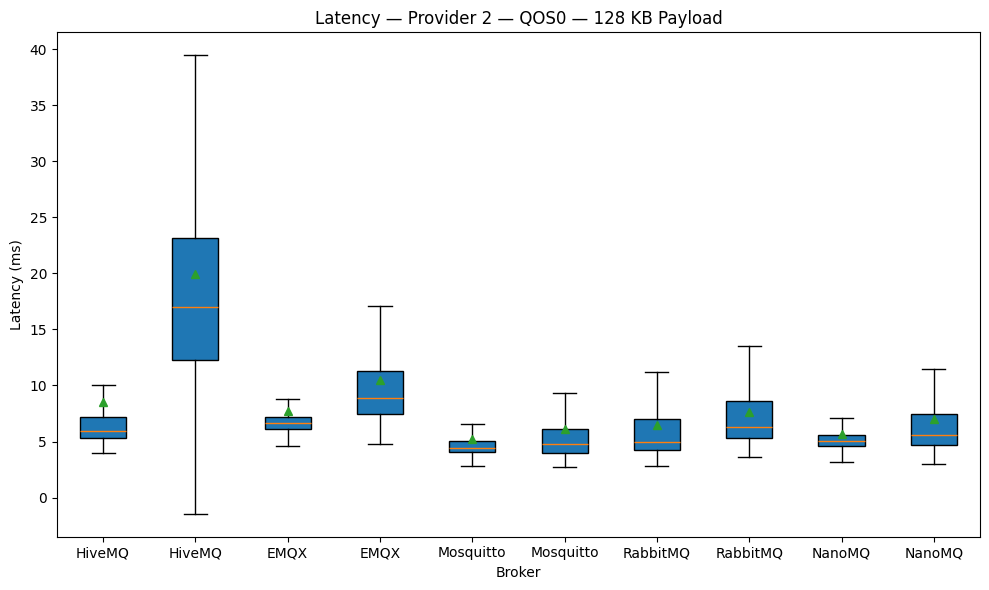

In [39]:
np_array = providers_sets[1]

for qos in qoss:
    for ps in _ps_values:
        data_ps = np_array[(np_array['qos'] == qos) & (np_array['payload_size'] == ps)]
        latency_data = []
        labels = []
        for aut in auts:
            data = data_ps[data_ps['aut'] == aut]['latency']
            if len(data) == 0:
                continue
            latency_data.append(data)
            labels.append(_broker_label(aut))

        if not latency_data:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(latency_data, patch_artist=True, showmeans=True, showfliers=False)
        ax.set_xticklabels(labels, rotation=0, ha='center')
        ax.set_xlabel('Broker')
        ax.set_ylabel('Latency (ms)')
        ax.set_title(f'Latency — Provider 2 — {qos.upper()} — {_ps_label(ps)} Payload')
        plt.show()


# Results Provider 2

In [40]:
# Stats

# Get data for all AUTs and QoS for provider 1
np_array= providers_sets[1]

for aut in auts:
    for qos in qoss:
        # Extract data for the current 'qos'
        data_for_qos = np_array[np_array['qos'] == qos]
        
        # Extract latency data for each 'aut' within the current 'qos'
        latency_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['latency']

        if len(latency_data_by_aut) == 0:
            continue
        
        delay = logs_parser.get_np_stats(latency_data_by_aut)
    
        rcv_msgs=len(latency_data_by_aut)
        avg_rcv_msgs = rcv_msgs/ logs_parser.NUM_RUNS
        
        # Extract uuid data for each 'aut' within the current 'qos'
        uuid_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['uuid']
        
        uniques = np.sum(np.unique_counts(uuid_data_by_aut).counts)
        duplicates_count = rcv_msgs - uniques
        avg_duplicates   = duplicates_count / logs_parser.NUM_RUNS
        
        expected_msgs = _expected_msgs_for_gateway(providers_tp[1].split("/")[-1])
        lost_msgs = expected_msgs - rcv_msgs
        avg_lost_msg = (lost_msgs - duplicates_count)/ logs_parser.NUM_RUNS 
        
        # Extract uuid data for each 'topic_size' within the current 'qos'
        topic_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['topic_size']
        
        # Global topic sizes
        topic_size = logs_parser.get_np_stats(topic_size_data_by_aut)
        
        # Extract uuid data for each 'topic_size' within the current 'qos'
        payload_size_data_by_aut = data_for_qos[data_for_qos['aut'] == aut]['payload_size']
            
        
        # Global Payload sizes
        payload=logs_parser.get_np_stats(payload_size_data_by_aut)
        
        
        print(f'\n{aut.upper()}/{qos.upper()}\t\n')
        print(f'Delay\tReceived Msg\tLost Msg\tDuplicated\tTopic')
        print(f'{delay["avg"]}\t{avg_rcv_msgs}\t{avg_lost_msg}\t{avg_duplicates}\t{topic_size["avg"]}')
        
        print(f'stdev_delay: {delay["stdev"]}')
        print(f'max_delay {delay["max"]}')
        print(f'min_delay {delay["min"]}')
        print(f'max_topic_size: {topic_size["max"]}')
        print(f'min_topic_size {topic_size["max"]}')
        print(f'avg_payload: {payload["avg"]}')
        print(f'p_stdev_payload: {payload["stdev"]}')
        print(f'p_max: {payload["max"]}')
        print(f'p_min: {payload["min"]}')
        


AUT0_HIVEMQ_125KB/QOS0	

Delay	Received Msg	Lost Msg	Duplicated	Topic
8.525333899656397	270.3636363636364	1547.8181818181818	0.0	19.0
stdev_delay: 31.4018921279623
max_delay 874.3193359375
min_delay 3.943603515625
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_HIVEMQ_125KB_FIXED/QOS0	

Delay	Received Msg	Lost Msg	Duplicated	Topic
19.948187658691406	1818.1818181818182	0.0	0.0	19.0
stdev_delay: 13.015746295207755
max_delay 619.372314453125
min_delay -33.994873046875
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_EMQX_125KB/QOS0	

Delay	Received Msg	Lost Msg	Duplicated	Topic
7.688040364583333	1786.3636363636363	31.818181818181817	0.0	19.0
stdev_delay: 26.553250934230928
max_delay 1085.981689453125
min_delay 4.050048828125
max_topic_size: 19
min_topic_size 19
avg_payload: 128000.0
p_stdev_payload: 0.0
p_max: 128000
p_min: 128000

AUT0_EMQX_125KB_FIXED/QOS0	